# Лабораторная работа №1 — ML-пайплайн на табличных данных

Краткий отчёт:

| Этап | Что сделано в ноутбуке |
|------|------------------------|
| EDA | Распределения числовых признаков, категории, корреляции, точечные графики связей |
| Предобработка | Дубликаты; проверка пропусков и «логики» значений; IQR-фильтр выбросов; One-Hot; `StandardScaler` (обучение только на train) |
| Признаки | Удаление слабых признаков после EDA; новые признаки (см. ячейку feature engineering) |
| Разбиение | train / val / test, `stratify` по `Depression`; медианы для заполнения — с train |
| Регрессия | `LinearRegression`; `SGDRegressor` |
| Классификация | `LogisticRegression`; `SGDClassifier`|
| Переобучение | Learning curve, сравнение train/val/test, разница AUC |
| Метрики | Регрессия: MAE, RMSE, R²; классификация: accuracy, precision, recall, ROC-AUC, log loss |



In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy import stats
%matplotlib inline
sns.set(color_codes=True)
random_st = 67


In [23]:
df = pd.read_csv('/content/student_lifestyle_100k.csv', sep=',')
print(df.head())
df.drop(columns='Student_ID',inplace=True) #ни на что не влияет


# Смотрим пропуски
print('Пропуски по столбцам:')
print(df.isnull().sum())
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()
if 'Age' in df.columns:
    bad = (df['Age'] < 15) | (df['Age'] > 70)
    if bad.any():
        print('Подозрительный возраст (строк):', bad.sum())
        df.loc[bad, 'Age'] = np.nan
    df['Age'] = df['Age'].clip(lower=17, upper=70)
for c in ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']:
    if c in df.columns:
        df.loc[df[c] < 0, c] = np.nan

df.info()


warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 5)
# экономим память
df['Physical_Activity'] = df['Physical_Activity'].astype('int16')
for i in ['Age','Stress_Level']:
  df[i]=df[i].astype('int8')
for i in ['Gender','Department']:
  df[i]=df[i].astype('category')
df.info()

#дубли
print('До', df.shape)
duplicate_rows_df = df[df.duplicated()]
print("Число дублей: ", duplicate_rows_df.shape)
df = df.drop_duplicates()
print('После', df.shape)

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  
Пропуски по столбцам:
Age                   0
Gender                0
Department            0
CGPA                  0

Категориальные признаки

Найдено категориальных признаков: 4
Признаки: ['Age', 'Stress_Level', 'Gender', 'Department']



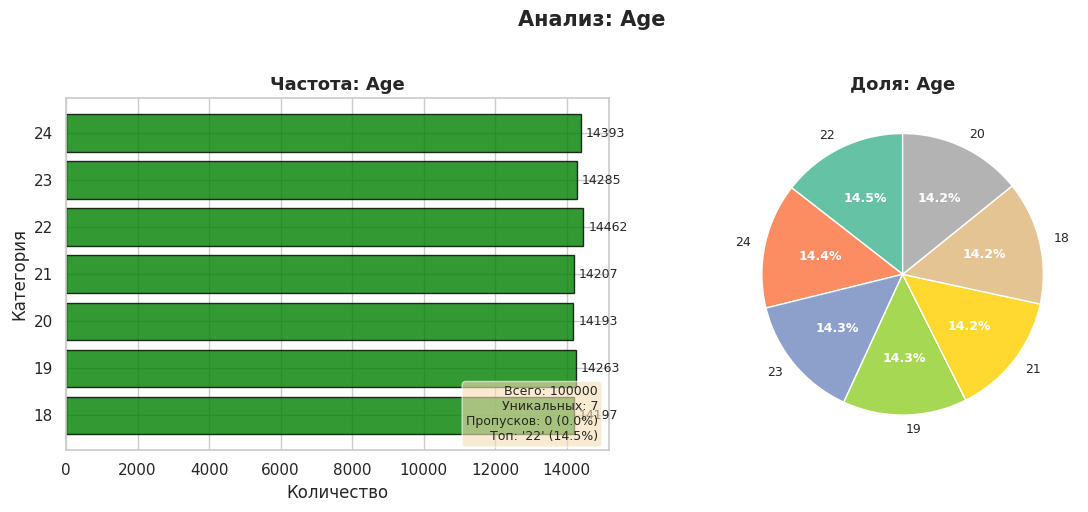

[OK] Age:
   |- Всего: 100000
   |- Уникальных: 7
   |- пропусков: 0 (0.0%)
   |- Топ 5 категорий:
      1. '22': 14462 (14.5%)
      2. '24': 14393 (14.4%)
      3. '23': 14285 (14.3%)
      4. '19': 14263 (14.3%)
      5. '21': 14207 (14.2%)
--------------------------------------------------------------------------------


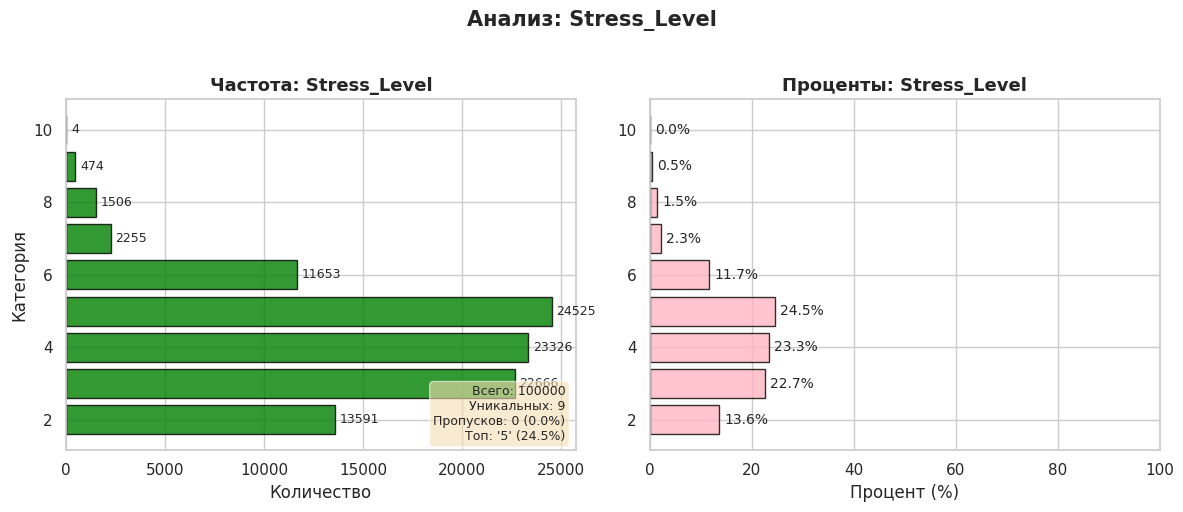

[OK] Stress_Level:
   |- Всего: 100000
   |- Уникальных: 9
   |- пропусков: 0 (0.0%)
   |- Топ 5 категорий:
      1. '5': 24525 (24.5%)
      2. '4': 23326 (23.3%)
      3. '3': 22666 (22.7%)
      4. '2': 13591 (13.6%)
      5. '6': 11653 (11.7%)
--------------------------------------------------------------------------------


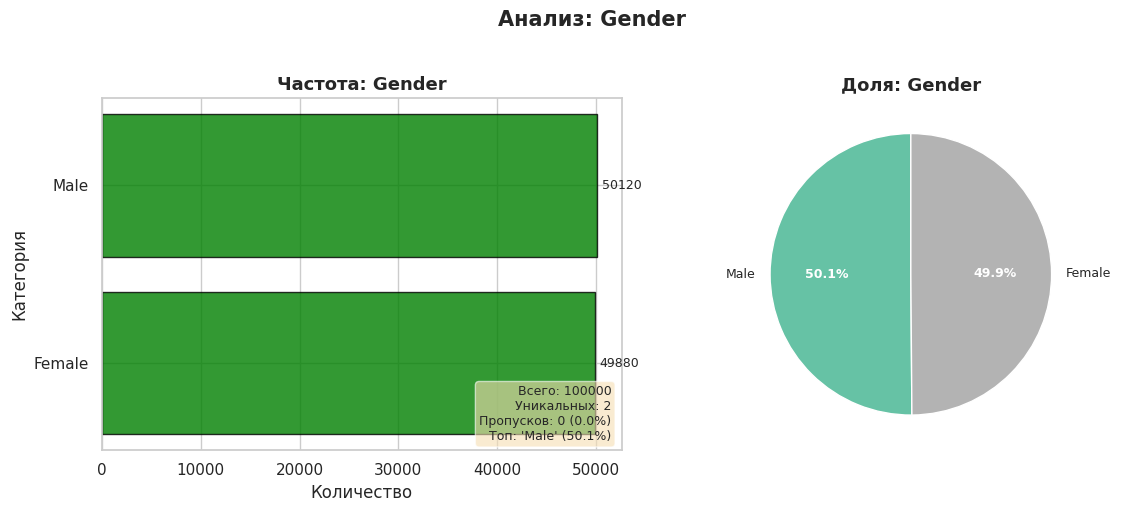

[OK] Gender:
   |- Всего: 100000
   |- Уникальных: 2
   |- пропусков: 0 (0.0%)
   |- Топ 5 категорий:
      1. 'Male': 50120 (50.1%)
      2. 'Female': 49880 (49.9%)
--------------------------------------------------------------------------------


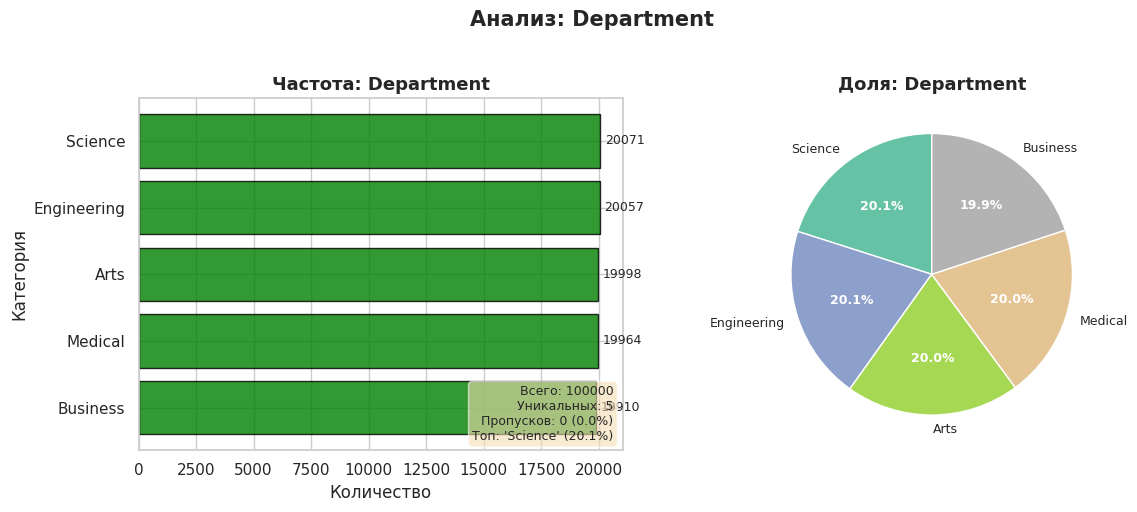

[OK] Department:
   |- Всего: 100000
   |- Уникальных: 5
   |- пропусков: 0 (0.0%)
   |- Топ 5 категорий:
      1. 'Science': 20071 (20.1%)
      2. 'Engineering': 20057 (20.1%)
      3. 'Arts': 19998 (20.0%)
      4. 'Medical': 19964 (20.0%)
      5. 'Business': 19910 (19.9%)
--------------------------------------------------------------------------------


In [24]:
# Категориальные признаки и малое число уникальных в числовых признаках
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_with_few_unique = [
    col for col in df.select_dtypes(include='number').columns
    if df[col].nunique() < 10 and df[col].nunique() > 1
]
cat_cols.extend(numeric_with_few_unique)
cat_cols = list(set(cat_cols)) # на всякий случай уберем повторения
print(f"Найдено категориальных признаков: {len(cat_cols)}")
print(f"Признаки: {cat_cols}\n")

def analyze_categorical(series, feature_name, top_n=10):
    """
    Анализирует распределение категориального признака.

    Параметры:
    - series: колонка из DataFrame
    - feature_name: имя признака для заголовков
    - top_n: сколько топ-категорий показать (если категорий много)
    """
    # Считаем значения, пропуски отдельно
    value_counts = series.value_counts(dropna=True)
    missing_count = series.isnull().sum()
    total_count = len(series)
    unique_count = value_counts.count()

    # Если категорий очень много — показываем только топ
    if unique_count > top_n:
        print(f"{feature_name}: {unique_count} уникальных категорий → показываем топ-{top_n}")
        value_counts = value_counts.head(top_n)
        other_count = total_count - missing_count - value_counts.sum()
    else:
        other_count = 0

    # ГРАФИК 1: Bar plot (абсолютные частоты)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar plot с горизонтальными столбцами (удобно для длинных названий)
    bars = axes[0].barh(value_counts.index[::-1], value_counts.values[::-1],
                        color='green', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Частота: {feature_name}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Количество')
    axes[0].set_ylabel('Категория')

    # Подписываем значения на столбцах (если их не слишком много)
    if len(value_counts) <= 10:
        for bar in bars:
            width = bar.get_width()
            axes[0].text(width + max(value_counts.values) * 0.01,
                        bar.get_y() + bar.get_height()/2,
                        f'{int(width)}', va='center', fontsize=9)

    # ГРАФИК 2: Pie chart с процентами (только для <= 8 категорий)
    if len(value_counts) <= 8 and other_count == 0:
        colors = plt.cm.Set2(np.linspace(0, 1, len(value_counts)))
        wedges, texts, autotexts = axes[1].pie(
            value_counts.values,
            labels=value_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors,
            textprops={'fontsize': 9}
        )
        # Делаем проценты читаемыми
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        axes[1].set_title(f'Доля: {feature_name}', fontsize=13, fontweight='bold')
    else:
        # Если категорий много — показываем проценты в виде bar plot
        percentages = value_counts / value_counts.sum() * 100
        bars = axes[1].barh(percentages.index[::-1], percentages.values[::-1],
                           color='lightpink', edgecolor='black', alpha=0.8)
        axes[1].set_title(f'Проценты: {feature_name}', fontsize=13, fontweight='bold')
        axes[1].set_xlabel('Процент (%)')
        axes[1].set_xlim(0, 100)

        # Подписываем проценты
        for bar in bars:
            width = bar.get_width()
            axes[1].text(width + 1, bar.get_y() + bar.get_height()/2,
                        f'{width:.1f}%', va='center', fontsize=10)

    # Статистика прямо на графике
    stats_text = (f"Всего: {total_count}\n"
                 f"Уникальных: {unique_count}\n"
                 f"Пропусков: {missing_count} ({missing_count/total_count*100:.1f}%)\n"
                 f"Топ: '{value_counts.index[0]}' ({value_counts.values[0]/total_count*100:.1f}%)")

    if other_count > 0:
        stats_text += f"\nДругое: {other_count} ({other_count/total_count*100:.1f}%)"

    axes[0].text(0.98, 0.02, stats_text, transform=axes[0].transAxes,
                 fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    plt.suptitle(f'Анализ: {feature_name}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Вывод в консоль
    print(f"[OK] {feature_name}:")
    print(f"   |- Всего: {total_count}")
    print(f"   |- Уникальных: {unique_count}")
    print(f"   |- пропусков: {missing_count} ({missing_count/total_count*100:.1f}%)")
    print(f"   |- Топ 5 категорий:")
    for i, (cat, count) in enumerate(value_counts.head(5).items(), 1):
        pct = count / total_count * 100
        print(f"      {i}. '{cat}': {count} ({pct:.1f}%)")
    if other_count > 0:
        print(f"   |- Другие: {other_count} ({other_count/total_count*100:.1f}%)")
    print("-" * 80)


#Запускаем анализ для всех категориальных признаков
if not cat_cols:
    print("Категориальные признаки не найдены.")
else:
    for col in cat_cols:
        analyze_categorical(df[col], col, top_n=10)



Числовые признаки

Найдено числовых признаков: 7



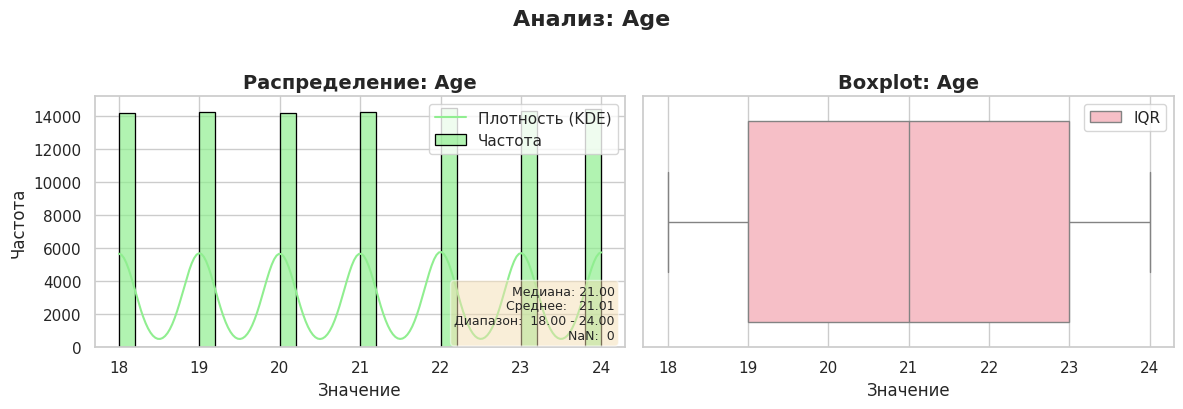

[OK] Age:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 0
--------------------------------------------------------------------------------


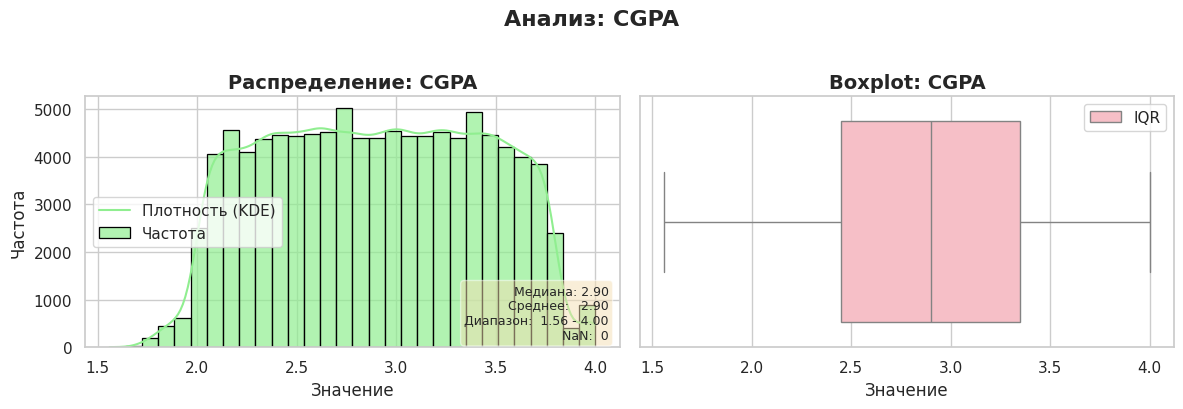

[OK] CGPA:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 0
--------------------------------------------------------------------------------


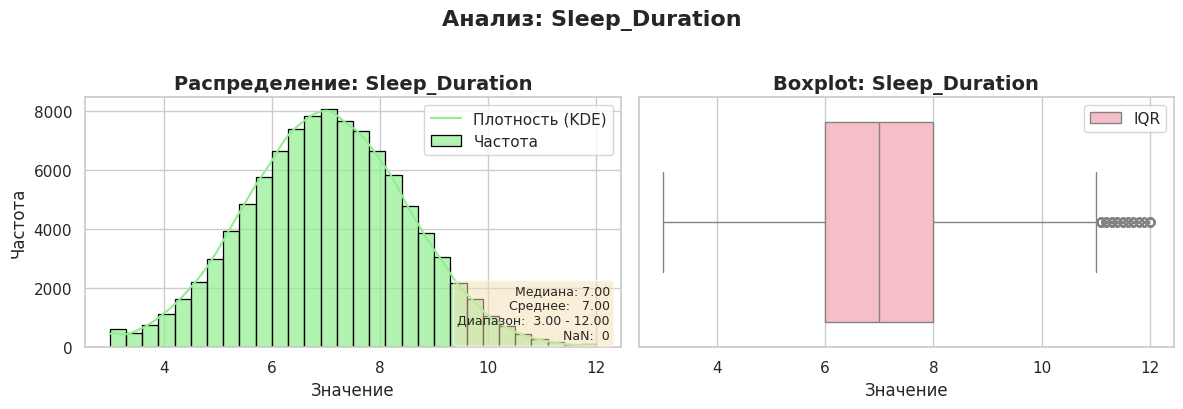

[OK] Sleep_Duration:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 369
--------------------------------------------------------------------------------


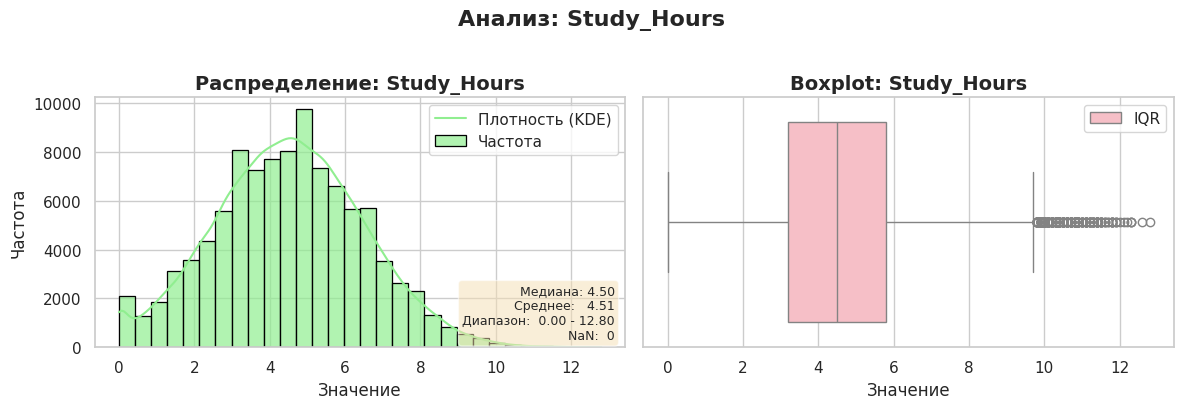

[OK] Study_Hours:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 432
--------------------------------------------------------------------------------


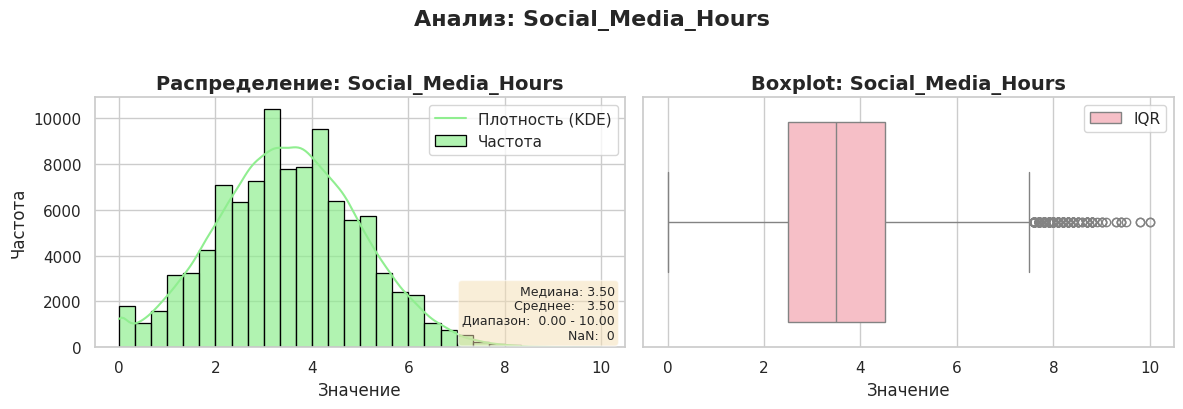

[OK] Social_Media_Hours:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 328
--------------------------------------------------------------------------------


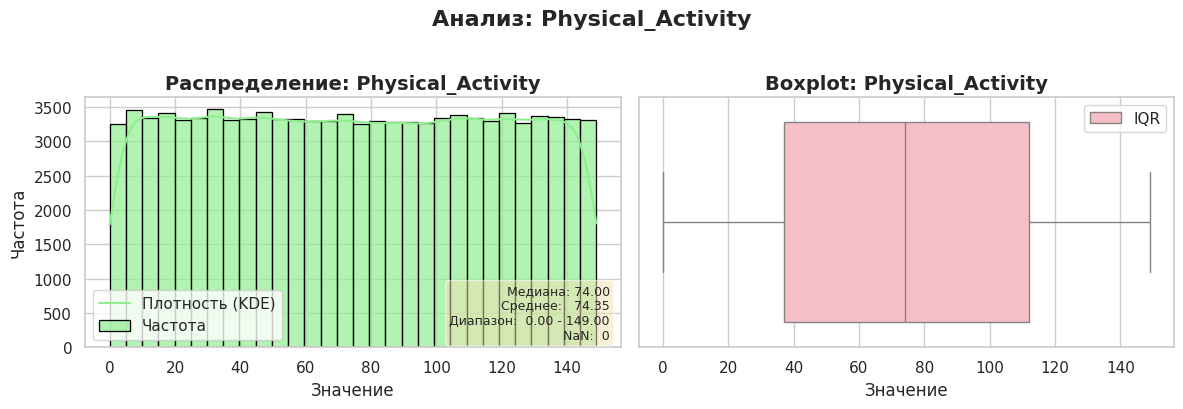

[OK] Physical_Activity:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 0
--------------------------------------------------------------------------------


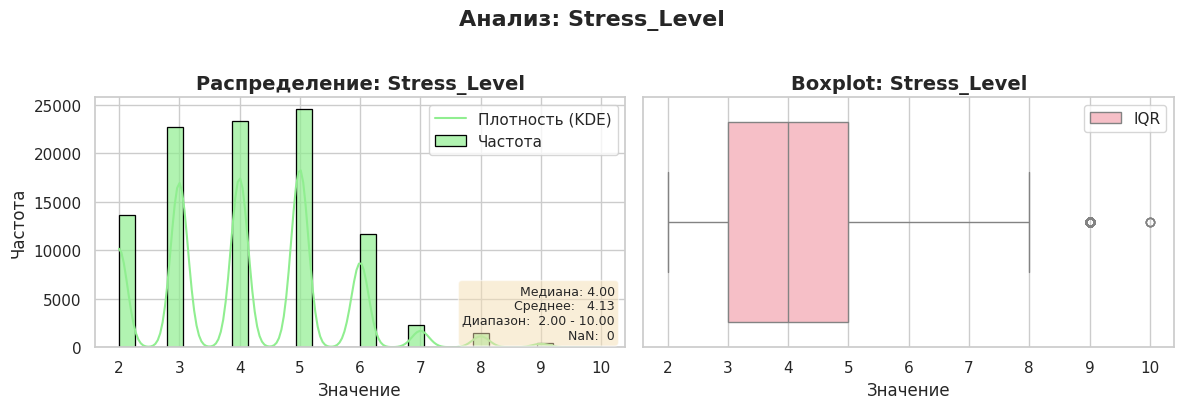

[OK] Stress_Level:
   |- Распределение: симметрично
   |- Пропуски: 0
   |- Выбросы (IQR): 478
--------------------------------------------------------------------------------


In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

if not numeric_cols:
    print("В датасете нет числовых признаков для визуализации")
else:
    print(f"Найдено числовых признаков: {len(numeric_cols)}\n")

    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Гистограмма + KDE
        sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0],
                     color='lightgreen', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Распределение: {col}', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Значение')
        axes[0].set_ylabel('Частота')
        axes[0].legend(['Плотность (KDE)', 'Частота'], loc='best')

        # Boxplot
        sns.boxplot(data=df, x=col, ax=axes[1], color='lightpink')
        axes[1].set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Значение')
        axes[1].legend(['IQR'], loc='best')

        # Статистика на графике
        stats_text = (f"Медиана: {df[col].median():.2f}\n"
                     f"Среднее:   {df[col].mean():.2f}\n"
                     f"Диапазон:  {df[col].min():.2f} - {df[col].max():.2f}\n"
                     f"NaN:  {df[col].isnull().sum()}")

        axes[0].text(0.98, 0.02, stats_text, transform=axes[0].transAxes,
                 fontsize=9, va='bottom', ha='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.suptitle(f'Анализ: {col}', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        # Расчет выбросов
        col_data = df[col].dropna()

        if len(col_data) > 0:
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
            missing_count = df[col].isnull().sum()

            skew = col_data.skew()
            if abs(skew) < 0.5:
                skew_text = "симметрично"
            elif skew > 0:
                skew_text = "правосторонняя ассиметрия"
            else:
                skew_text = "левосторонняя ассиметрия"

            # Вывод в консоль
            print(f"[OK] {col}:")
            print(f"   |- Распределение: {skew_text}")
            print(f"   |- Пропуски: {missing_count}")
            print(f"   |- Выбросы (IQR): {outliers_count}")
            print("-" * 80)
        else:
            print(f"[WARN] {col}: нет данных для анализа")
            print("-" * 80)

Завсимость уровня стресса от сна для мужчин и женщин

/tmp/ipykernel_4061/1150367504.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper right')
/tmp/ipykernel_4061/1150367504.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='upper right')


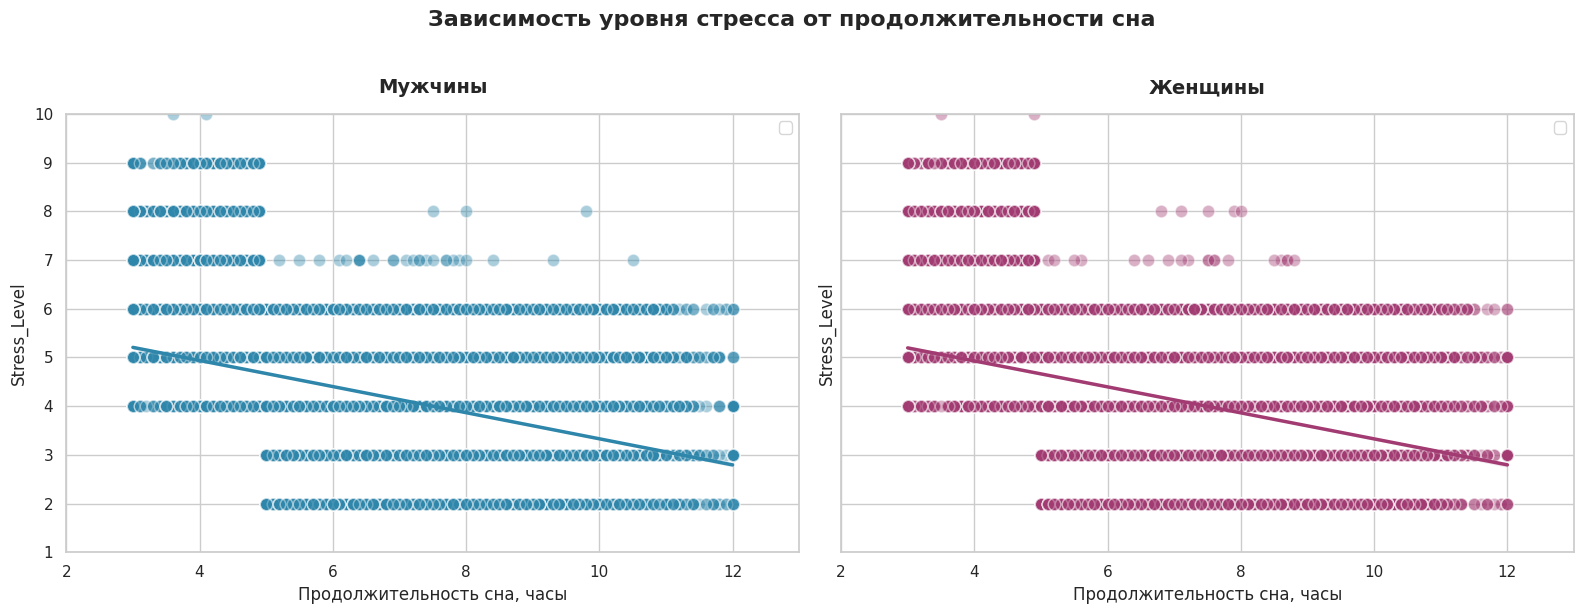

СТАТИСТИКА ПО ГРУППАМ

Male:
  Количество наблюдений: 50120
  Средний уровень стресса: 4.13 ± 1.42
  Средний сон: 7.00 ± 1.50 ч
  Коэффициент корреляции: -0.283
  R²: 0.080
  p-value: 0.0000
  Уравнение: Stress_Level = -0.268 × sleep + 6.010

Female:
  Количество наблюдений: 49880
  Средний уровень стресса: 4.13 ± 1.43
  Средний сон: 6.99 ± 1.50 ч
  Коэффициент корреляции: -0.280
  R²: 0.079
  p-value: 0.0000
  Уравнение: Stress_Level = -0.267 × sleep + 5.996


In [7]:
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Цветовая палитра
colors = {'Male': '#2E86AB', 'Female': '#A23B72'}

# тут незначительное изменение кода произошло: сначала график был scatterplot и вручную строилась линия регрессии и доверительный интервал,
# затем была найдена более удобная функция, которая и написана снизу, которая автоматически рассчитывает и строит это.
# Смысл графика и его вид не изменился, просто меньше строк кода.

# Левый график: Мужчины
male_data = df[df['Gender'] == 'Male'].copy()
sns.regplot(
    data=male_data,
    x='Sleep_Duration',
    y='Stress_Level',
    ax=axes[0],
    color=colors['Male'],
    scatter_kws={'alpha': 0.4, 's': 80, 'edgecolor': 'white'},
    line_kws={'linewidth': 2.5},
    ci=95 #доверительный интервал 95%
)

axes[0].set_title('Мужчины', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Продолжительность сна, часы', fontsize=12)
axes[0].set_ylabel('Stress_Level', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].set_ylim(1, 10)
axes[0].set_xlim(2, 13)

# Правый график: Женщины
female_data = df[df['Gender'] == 'Female'].copy()
sns.regplot(
    data=female_data,
    x='Sleep_Duration',
    y='Stress_Level',
    ax=axes[1],
    color=colors['Female'],
    scatter_kws={'alpha': 0.4, 's': 80, 'edgecolor': 'white'},
    line_kws={'linewidth': 2.5},
    ci=95
)

axes[1].set_title('Женщины', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Продолжительность сна, часы', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].set_xlim(2, 13)

# Общий заголовок
fig.suptitle('Зависимость уровня стресса от продолжительности сна',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Вывод статистики
print("=" * 60)
print("СТАТИСТИКА ПО ГРУППАМ")
print("=" * 60)

for gender in ['Male', 'Female']:
    subset = df[df['Gender'] == gender]
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        subset['Sleep_Duration'], subset['Stress_Level']
    )
    print(f"\n{gender}:")
    print(f"  Количество наблюдений: {len(subset)}")
    print(f"  Средний уровень стресса: {subset['Stress_Level'].mean():.2f} ± {subset['Stress_Level'].std():.2f}")
    print(f"  Средний сон: {subset['Sleep_Duration'].mean():.2f} ± {subset['Sleep_Duration'].std():.2f} ч")
    print(f"  Коэффициент корреляции: {r_value:.3f}")
    print(f"  R²: {r_value**2:.3f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Уравнение: Stress_Level = {slope:.3f} × sleep + {intercept:.3f}")

Можем сделать вывод, что пол практически не влияет на зависимости, а значит мы можем убрать эту колонку при дальнейшем обучении

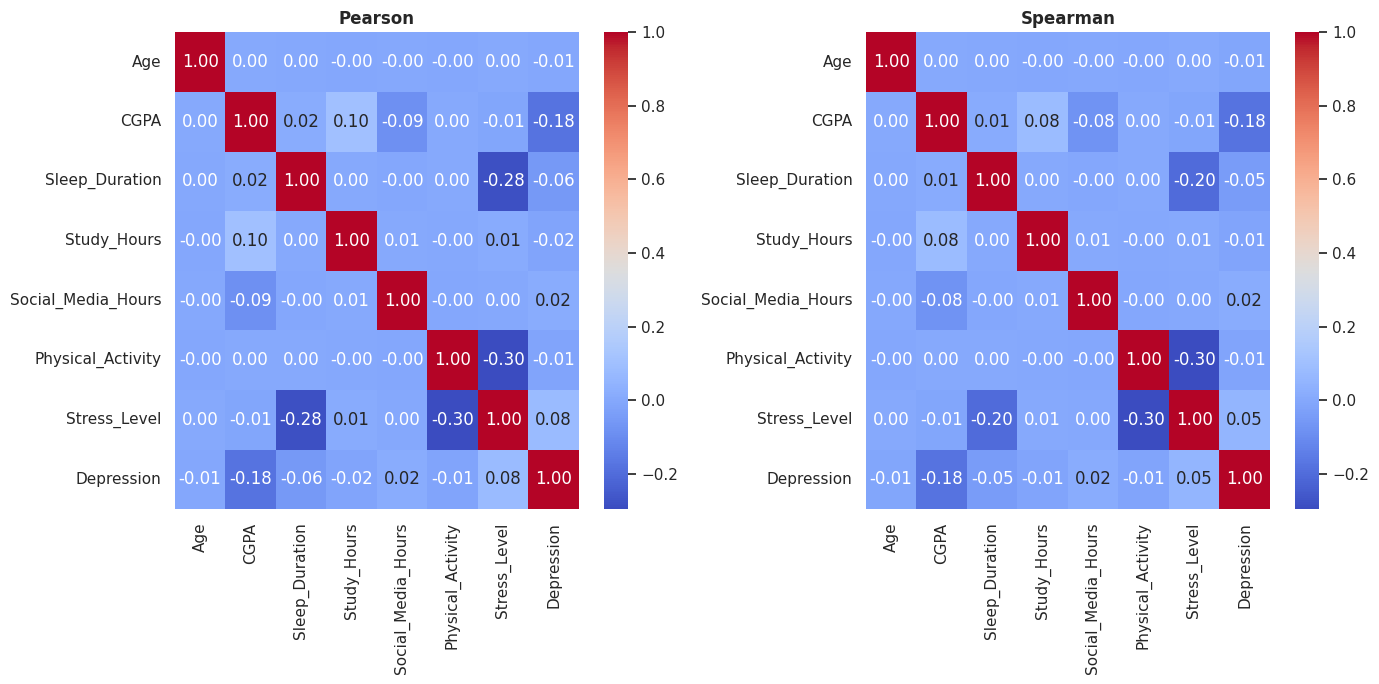

In [8]:
#Относительно прошлой версии, графики теперь стоят рядом, а не друг под другом. Логика не поменялась, только внешний вид
fig,axes = plt.subplots(1,2,figsize=(14,7))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm',ax=axes[0])
axes[0].set_title("Pearson",fontsize=12,fontweight='bold')

sns.heatmap(df.corr(numeric_only=True,method='spearman'), annot = True, fmt='.2f',cmap='coolwarm',ax=axes[1])
axes[1].set_title("Spearman",fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

Сильнее всего коррелируют количество сна+физическая активность и уровень стресса

/tmp/ipykernel_4061/2343971971.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_4061/2343971971.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


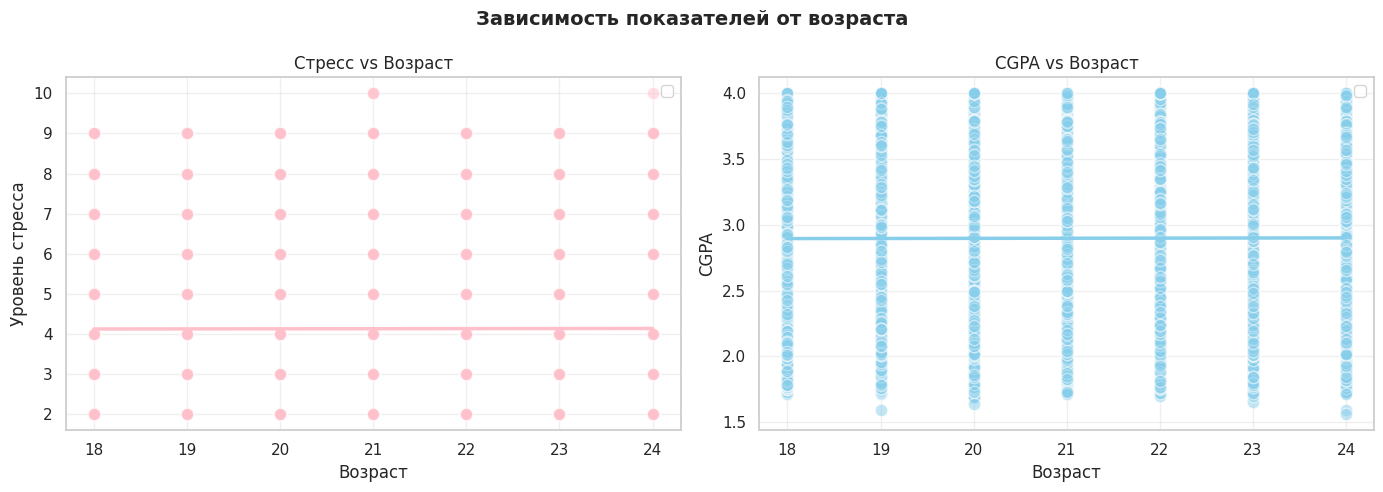

КОРРЕЛЯЦИЯ С ВОЗРАСТОМ

Stress_Level:
  Корреляция (r): 0.0030
  R²: 0.0000
  p-value: 3.4294e-01
  Уравнение: Stress_Level = 0.0021 × age + 4.0868

CGPA:
  Корреляция (r): 0.0032
  R²: 0.0000
  p-value: 3.0432e-01
  Уравнение: CGPA = 0.0009 × age + 2.8802


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Левый: Уровень стресса от возраста
sns.regplot(
    data=df,
    x='Age',
    y='Stress_Level',
    ax=axes[0],
    color='pink',
    scatter_kws={'alpha': 0.5, 's': 80, 'edgecolor': 'white'},
    line_kws={'linewidth': 2.5},
    ci=95
)

axes[0].set_title('Стресс vs Возраст')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Уровень стресса')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Правый: CGPA от возраста
sns.regplot(
    data=df,
    x='Age',
    y='CGPA',
    ax=axes[1],
    color='skyblue',
    scatter_kws={'alpha': 0.5, 's': 80, 'edgecolor': 'white'},
    line_kws={'linewidth': 2.5},
    ci=95
)

axes[1].set_title('CGPA vs Возраст')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('CGPA')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Зависимость показателей от возраста', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Статистика
print("=" * 60)
print("КОРРЕЛЯЦИЯ С ВОЗРАСТОМ")
print("=" * 60)

for target in ['Stress_Level', 'CGPA']:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df['Age'], df[target]
    )
    print(f"\n{target}:")
    print(f"  Корреляция (r): {r_value:.4f}")
    print(f"  R²: {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4e}")
    print(f"  Уравнение: {target} = {slope:.4f} × age + {intercept:.4f}")

Возраст также не влияет на признаки

In [10]:
# Удалим стобцы возраста и пола

df=df.drop(columns=['Gender', 'Age'])


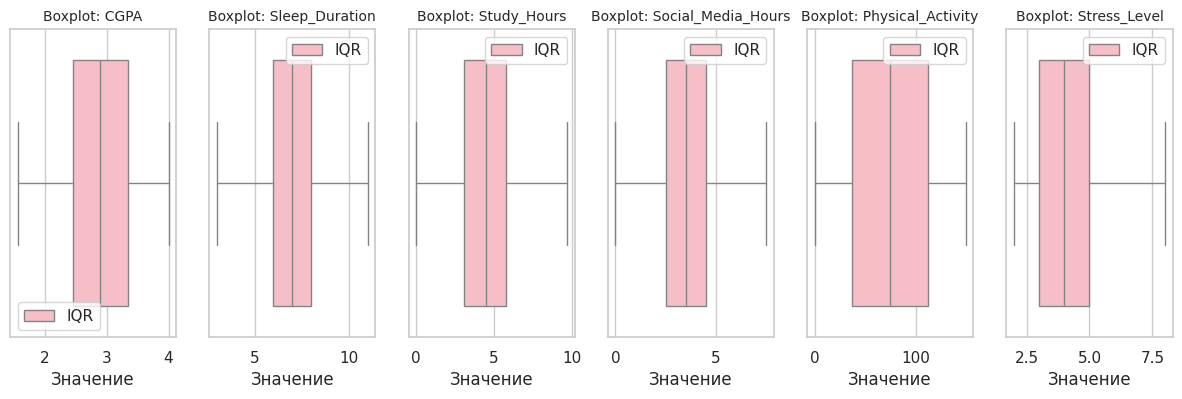

In [11]:
# Убираем выбросы

numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    col_data = df[col].dropna()
    if len(col_data) > 0:
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = ~((df[col] < lower_bound) | (df[col] > upper_bound))
        df = df[mask]

# Сброс индекса после фильтрации строк
df.reset_index(drop=True, inplace=True)


fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
for i,col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=col, ax=axes[i], color='lightpink')
        axes[i].set_title(f'Boxplot: {col}', fontsize=10)
        axes[i].set_xlabel('Значение')
        axes[i].legend(['IQR'], loc='best')

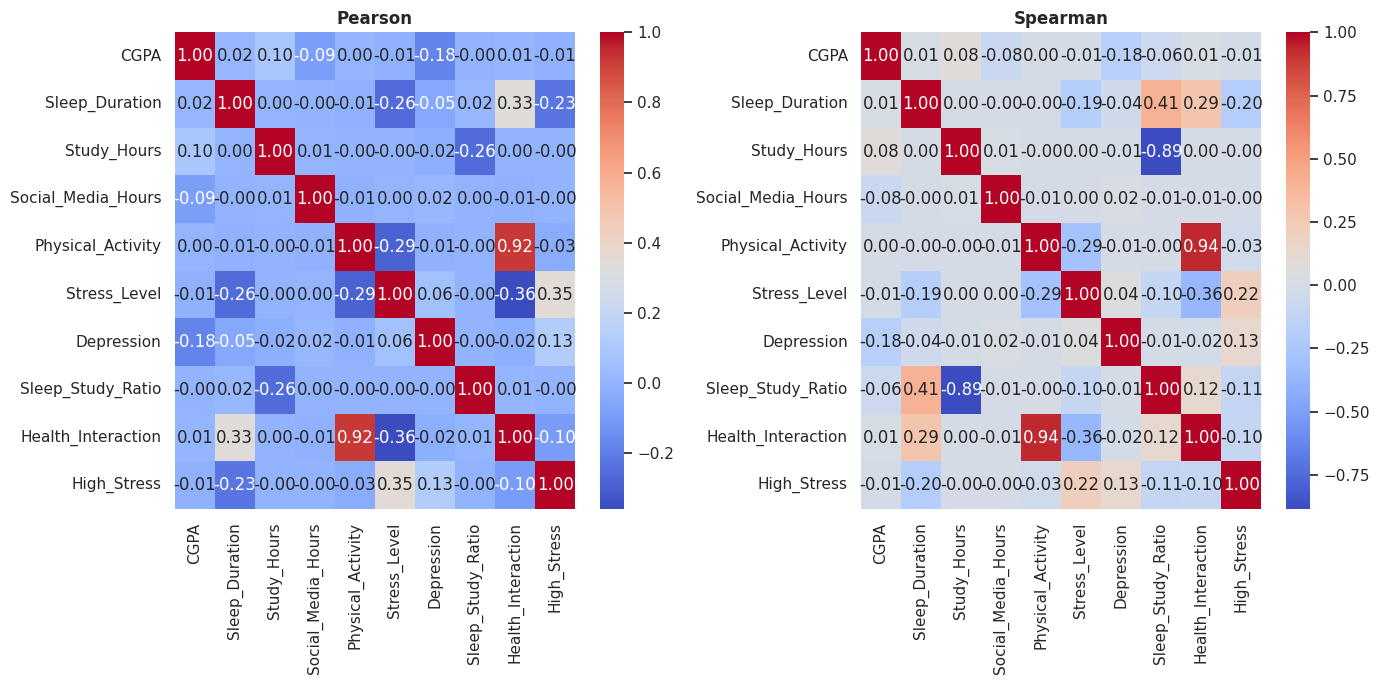

In [12]:
# Feature Engeering
df['Sleep_Study_Ratio'] = df['Sleep_Duration'] / (df['Study_Hours']+0.0001) # чтобы избежать деления на 0
#df['Sleep_Duration_sq'] = df['Sleep_Duration'] ** 2
df['Health_Interaction'] = df['Physical_Activity'] * df['Sleep_Duration']
df['High_Stress'] = (df['Stress_Level'] >= 8).astype(int)
numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig,axes = plt.subplots(1,2,figsize=(14,7))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm',ax=axes[0])
axes[0].set_title("Pearson",fontsize=12,fontweight='bold')

sns.heatmap(df.corr(numeric_only=True,method='spearman'), annot = True, fmt='.2f',cmap='coolwarm',ax=axes[1])
axes[1].set_title("Spearman",fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Кодирование
from sklearn.preprocessing import OneHotEncoder
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_encoded_data = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)
# Удаляем оригинальные категориальные колонки из основного df
df = df.drop(columns=cat_cols)
# Объединяем исходный df с закодированными данными
df = pd.concat([df, ohe_df], axis=1)
print(df.head())

   CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  Physical_Activity  \
0  3.50             7.3          3.3                 3.4                114   
1  2.72             5.5          7.2                 6.0                142   
2  3.01             5.4          2.3                 1.8                137   
3  3.63             8.1          2.0                 4.6                130   
4  3.14             6.8          2.6                 4.3                  4   

   Stress_Level  Depression  Sleep_Study_Ratio  Health_Interaction  \
0             5       False           2.212054               832.2   
1             2       False           0.763878               781.0   
2             3       False           2.347724               739.8   
3             3       False           4.049798              1053.0   
4             6       False           2.615284                27.2   

   High_Stress  Department_Business  Department_Engineering  \
0            0                  0.0      

Используем One-Hot encoder, чтобы модель не придавала значения цифрам, как если в LabelEncoder. А также потому что у нас небольшое количество уникальных значений у категориальных признаков

In [14]:
# Разделение выборки
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Целевая переменная
X = df.drop(columns=['CGPA', 'Depression'])
y_reg = df['CGPA']
y_clf = df['Depression'].astype(int)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X_train_val, X_test, y_reg_train_val, y_reg_test, y_clf_train_val, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=random_st,
    stratify=y_clf
)

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_train_val, y_reg_train_val, y_clf_train_val,
    test_size=0.2,
    random_state=random_st,
    stratify=y_clf_train_val
)

# Очистка данных перед масштабированием (на всякий случай проверка если неопределенности)
for df in [X_train, X_val, X_test]:
    # Заменить бесконечности на NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Заполнить NaN медианой из train
    df.fillna(X_train.median(), inplace=True)


# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled = scaler.transform(X_val[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])
# Добавляем категориальные признаки
if len(X.columns) > len(numeric_cols):
    cat_cols = [c for c in X.columns if c not in numeric_cols]
    X_train_scaled = np.hstack([X_train_scaled, X_train[cat_cols]])
    X_val_scaled = np.hstack([X_val_scaled, X_val[cat_cols]])
    X_test_scaled = np.hstack([X_test_scaled, X_test[cat_cols]])


используем StandartScaler потому что работаем с линейными моделями, нам неважен диапазон в отличие от MinMaxScaler, у нас нормальное симметричное распределение. Также MinMaxScaler очень чувствителен к выбросам.

Train Loss (MSE): 0.2769
Val Loss (MSE):   0.2808
Test Loss (MSE):  0.2789


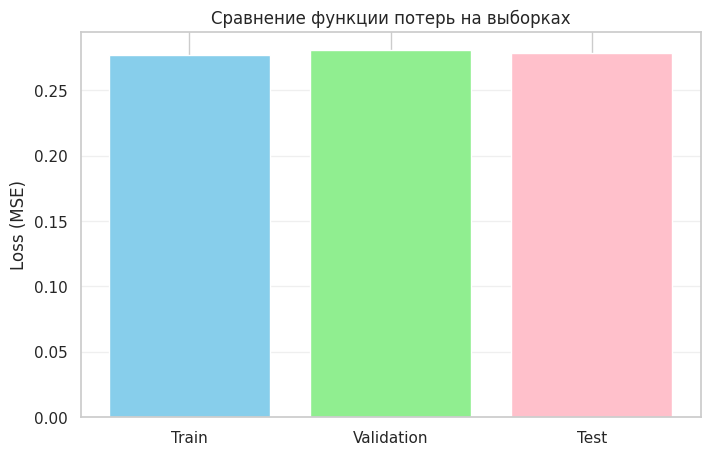


 Метрики для Train:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0177
  MAPE: 16.50%

 Метрики для Validation:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0181
  MAPE: 16.69%

 Метрики для Test:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0176
  MAPE: 16.59%


In [15]:
# Обучение
# Линейная регрессия
model_reg = LinearRegression()
model_reg.fit(X_train_scaled, y_reg_train)

y_reg_train_pred = model_reg.predict(X_train_scaled)
y_reg_val_pred = model_reg.predict(X_val_scaled)
y_reg_test_pred = model_reg.predict(X_test_scaled)

train_loss = mean_squared_error(y_reg_train, y_reg_train_pred)
val_loss = mean_squared_error(y_reg_val, y_reg_val_pred)
test_loss = mean_squared_error(y_reg_test, y_reg_test_pred)

print(f"Train Loss (MSE): {train_loss:.4f}")
print(f"Val Loss (MSE):   {val_loss:.4f}")
print(f"Test Loss (MSE):  {test_loss:.4f}")

# График сравнения
plt.figure(figsize=(8, 5))
plt.bar(['Train', 'Validation', 'Test'], [train_loss, val_loss, test_loss], color=['skyblue', 'lightgreen', 'pink'])
plt.ylabel('Loss (MSE)')
plt.title('Сравнение функции потерь на выборках')
plt.grid(axis='y', alpha=0.3)
plt.show()

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Оценка на обеих выборках
train_metrics = evaluate_model(y_reg_train, y_reg_train_pred, "Train")
val_metrics = evaluate_model(y_reg_val,y_reg_val_pred, "Validation")
test_metrics = evaluate_model(y_reg_test, y_reg_test_pred, "Test")

Все метрики, кроме R^2 должны стремиться к 0, а R^2 к 1. Но по данным метрикам можно сказать, что модель не очень хорошо предсказывает, а скорее угадывает среднее значение.

Попробуем модель со стохастическим градиентным спуском

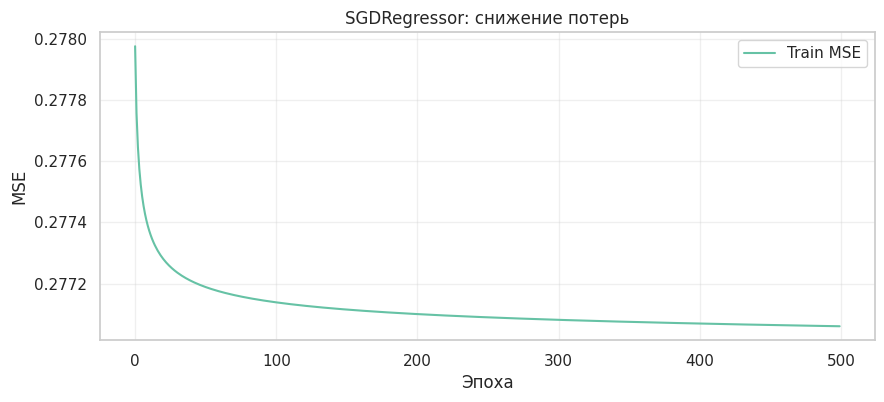


 Метрики для Test SGD:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0171
  MAPE: 16.57%


In [16]:
# Стохастический градиент (регрессия)
from sklearn.linear_model import SGDRegressor

def train_sgd_with_loss(X, y, epochs=500):
    model = SGDRegressor(
        loss='squared_error',
        max_iter=500,
        warm_start=True,
        random_state=random_st,
    )
    losses = []
    for _ in range(epochs):
        model.partial_fit(X, y)
        y_pred = model.predict(X)
        losses.append(mean_squared_error(y, y_pred))
    return model, losses

model_sgd_loss, loss_history = train_sgd_with_loss(X_train_scaled, y_reg_train, epochs=500)
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label='Train MSE')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('SGDRegressor: снижение потерь')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

y_sgd_pred = model_sgd_loss.predict(X_test_scaled)
sgd_metrics=evaluate_model(y_reg_test, y_sgd_pred, "Test SGD")


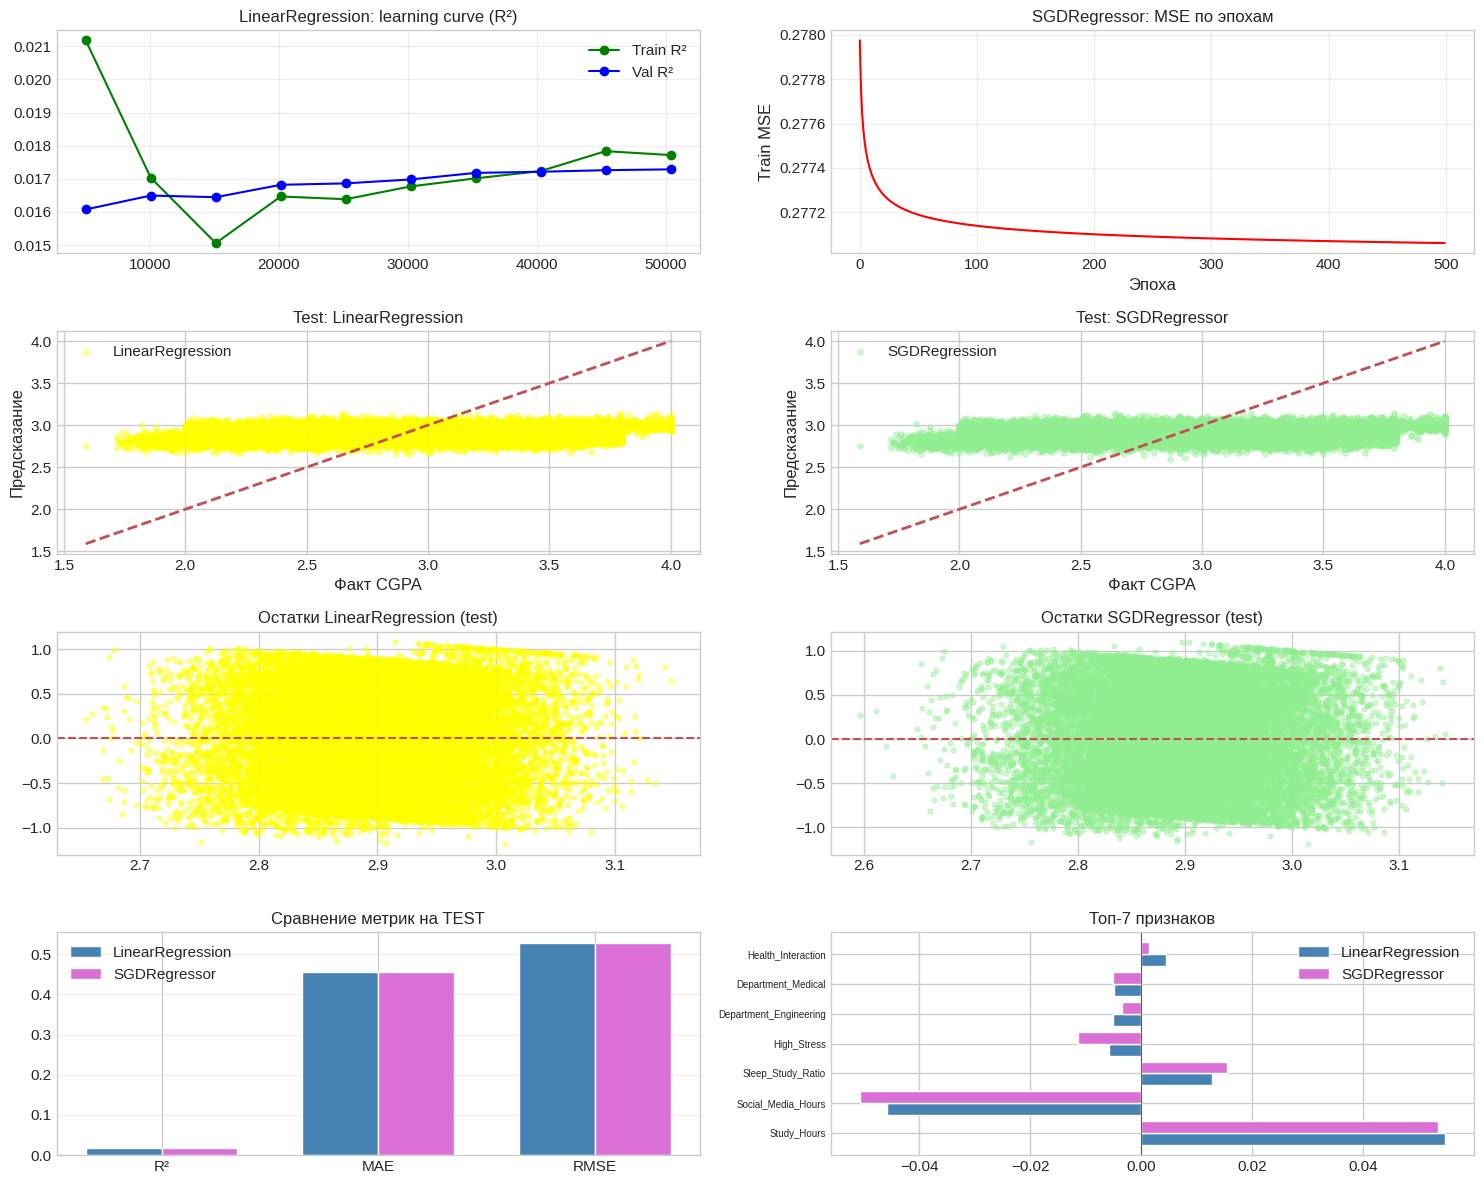


Диагностика LR: разница R² (Train - Test): 0.0001


In [17]:
# Графики: LinearRegression vs SGDRegressor
from sklearn.model_selection import learning_curve

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 12))

# ряд 1: learning curve LR | кривая потерь SGD
ax1 = plt.subplot(4, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model_reg, X_train_scaled, y_reg_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2', n_jobs=-1, random_state=random_st
)
ax1.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='green', label='Train R²')
ax1.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='blue', label='Val R²')
ax1.set_title('LinearRegression: learning curve (R²)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(4, 2, 2)
ax2.plot(loss_history, color='red')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Train MSE')
ax2.set_title('SGDRegressor: MSE по эпохам')
ax2.grid(True, alpha=0.3)

# ряд 2: actual vs predicted
ax3 = plt.subplot(4, 2, 3)
ax3.scatter(y_reg_test, y_reg_test_pred, alpha=0.4, s=15,color='yellow', label='LinearRegression')
mn, mx = float(y_reg_test.min()), float(y_reg_test.max())
ax3.plot([mn, mx], [mn, mx], 'r--', lw=2)
ax3.set_xlabel('Факт CGPA')
ax3.set_ylabel('Предсказание')
ax3.set_title('Test: LinearRegression')
ax3.legend()

ax4 = plt.subplot(4, 2, 4)
ax4.scatter(y_reg_test, y_sgd_pred, alpha=0.4, s=15, color='lightgreen', label='SGDRegression')
ax4.plot([mn, mx], [mn, mx], 'r--', lw=2)
ax4.set_xlabel('Факт CGPA')
ax4.set_ylabel('Предсказание')
ax4.set_title('Test: SGDRegressor')
ax4.legend()

# ряд 3: остатки
res_lr = y_reg_test - y_reg_test_pred
res_sgd = y_reg_test - y_sgd_pred
ax5 = plt.subplot(4, 2, 5)
ax5.scatter(y_reg_test_pred, res_lr, alpha=0.4, s=12,color='yellow')
ax5.axhline(0, color='r', ls='--')
ax5.set_title('Остатки LinearRegression (test)')
ax6 = plt.subplot(4, 2, 6)
ax6.scatter(y_sgd_pred, res_sgd, alpha=0.4, s=12, color='lightgreen')
ax6.axhline(0, color='r', ls='--')
ax6.set_title('Остатки SGDRegressor (test)')

# ряд 4: метрики на test — столбики рядом
ax7 = plt.subplot(4, 2, 7)
names = ['R²', 'MAE', 'RMSE']
x = np.arange(len(names))
w = 0.35
m_lr = [test_metrics['R2'], test_metrics['MAE'], test_metrics['RMSE']]
m_sgd = [sgd_metrics['R2'], sgd_metrics['MAE'], sgd_metrics['RMSE']]
ax7.bar(x - w/2, m_lr, w, label='LinearRegression', color='steelblue')
ax7.bar(x + w/2, m_sgd, w, label='SGDRegressor', color='orchid')
ax7.set_xticks(x)
ax7.set_xticklabels(names)
ax7.set_title('Сравнение метрик на TEST')
ax7.legend()
ax7.grid(True, axis='y', alpha=0.3)

# топ коэффициентов рядом
if hasattr(X, 'columns'):
    fn = X.columns.tolist()
else:
    fn = [f'f{i}' for i in range(X_train_scaled.shape[1])] # чтобы было хоть какое-то имя признака
ax8 = plt.subplot(4, 2, 8)
coef_lr = pd.DataFrame({'f': fn, 'c': model_reg.coef_}).assign(_a=lambda d: d['c'].abs()).sort_values('_a', ascending=False).head(7).drop(columns='_a')
sg_series = pd.Series(model_sgd_loss.coef_.ravel(), index=fn)
topf = coef_lr['f'].tolist()
lr_c = coef_lr.set_index('f').loc[topf]['c'].values
sg_c = sg_series.reindex(topf).values
ypos = np.arange(len(topf))
ax8.barh(ypos - 0.2, lr_c, 0.4, label='LinearRegression', color='steelblue')
ax8.barh(ypos + 0.2, sg_c, 0.4, label='SGDRegressor', color='orchid')
ax8.set_yticks(ypos)
ax8.set_yticklabels(topf, fontsize=7)
ax8.set_title('Топ-7 признаков')
ax8.legend()
ax8.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

r2_diff = train_metrics['R2'] - test_metrics['R2']
print(f"\nДиагностика LR: разница R² (Train - Test): {r2_diff:.4f}")


### Интерпретация: регрессия (CGPA)

**Почему такие метрики.** Для задачи восстановления непрерывной величины (успеваемость) стандартно используют:
- **MAE** — средняя ошибка в тех же единицах, что и CGPA; легко объясняется («в среднем ошибаемся на … балла»).
- **RMSE** — сильнее штрафует редкие большие ошибки; полезно, если важны выбросы.
- **R²** — доля дисперсии ответа, которую модель объясняет линейной комбинацией признаков; удобно сравнивать модели на одном датасете. При слабой линейной связи и «ровном» распределении CGPA R² часто близок к нулю — это не обязательно ошибка кода, а ограничение линейной модели и данных.
- **MAPE** — относительная ошибка; имеет смысл, когда цель далека от нуля (у CGPA так и есть).

**Почему LinearRegression и SGDRegressor дают почти одинаковые метрики.** Оба решают одинаковую задачу минимизации MSE на обучающих данных; при достаточном числе эпох и сходимости SGD находит решение, близкое к аналитическому (OLS). Различия на графиках коэффициентов обычно малы.

**От чего зависят «плохие» R² / MAE.** Узкий диапазон CGPA у студентов, слабая линейная зависимость от режима и стресса, нелинейные эффекты, шум в данных — всё это тянет прогноз к среднему и даёт низкий R².


Train Loss (Log Loss): 0.6768
Val Loss (Log Loss):   0.6768
Test Loss (Log Loss):  0.6771


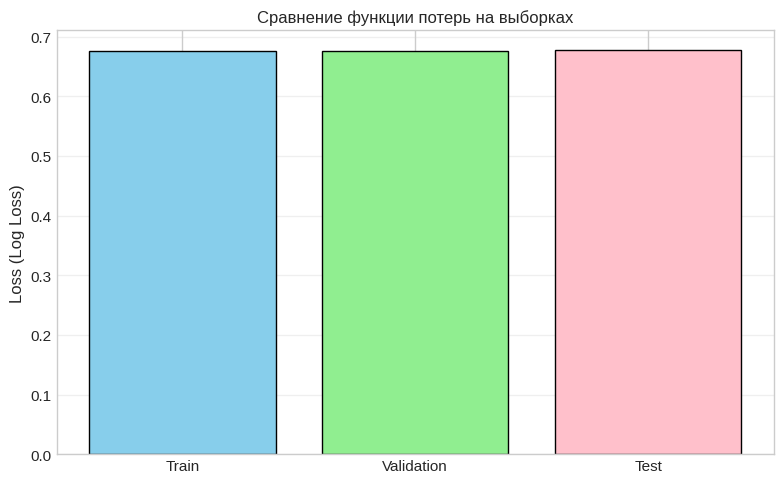


 Метрики для Train:
  Accuracy:  0.7002
  Precision: 0.1232
  Recall:    0.3302
  AUC-ROC:   0.5535
  Log Loss:  0.6768

 Метрики для Validation:
  Accuracy:  0.7007
  Precision: 0.1280
  Recall:    0.3468
  AUC-ROC:   0.5595
  Log Loss:  0.6768

 Метрики для Test:
  Accuracy:  0.7010
  Precision: 0.1279
  Recall:    0.3461
  AUC-ROC:   0.5586
  Log Loss:  0.6771

 Classification Report (Test):
               precision    recall  f1-score   support

No Depression       0.91      0.74      0.82     17729
   Depression       0.13      0.35      0.19      1953

     accuracy                           0.70     19682
    macro avg       0.52      0.54      0.50     19682
 weighted avg       0.83      0.70      0.75     19682



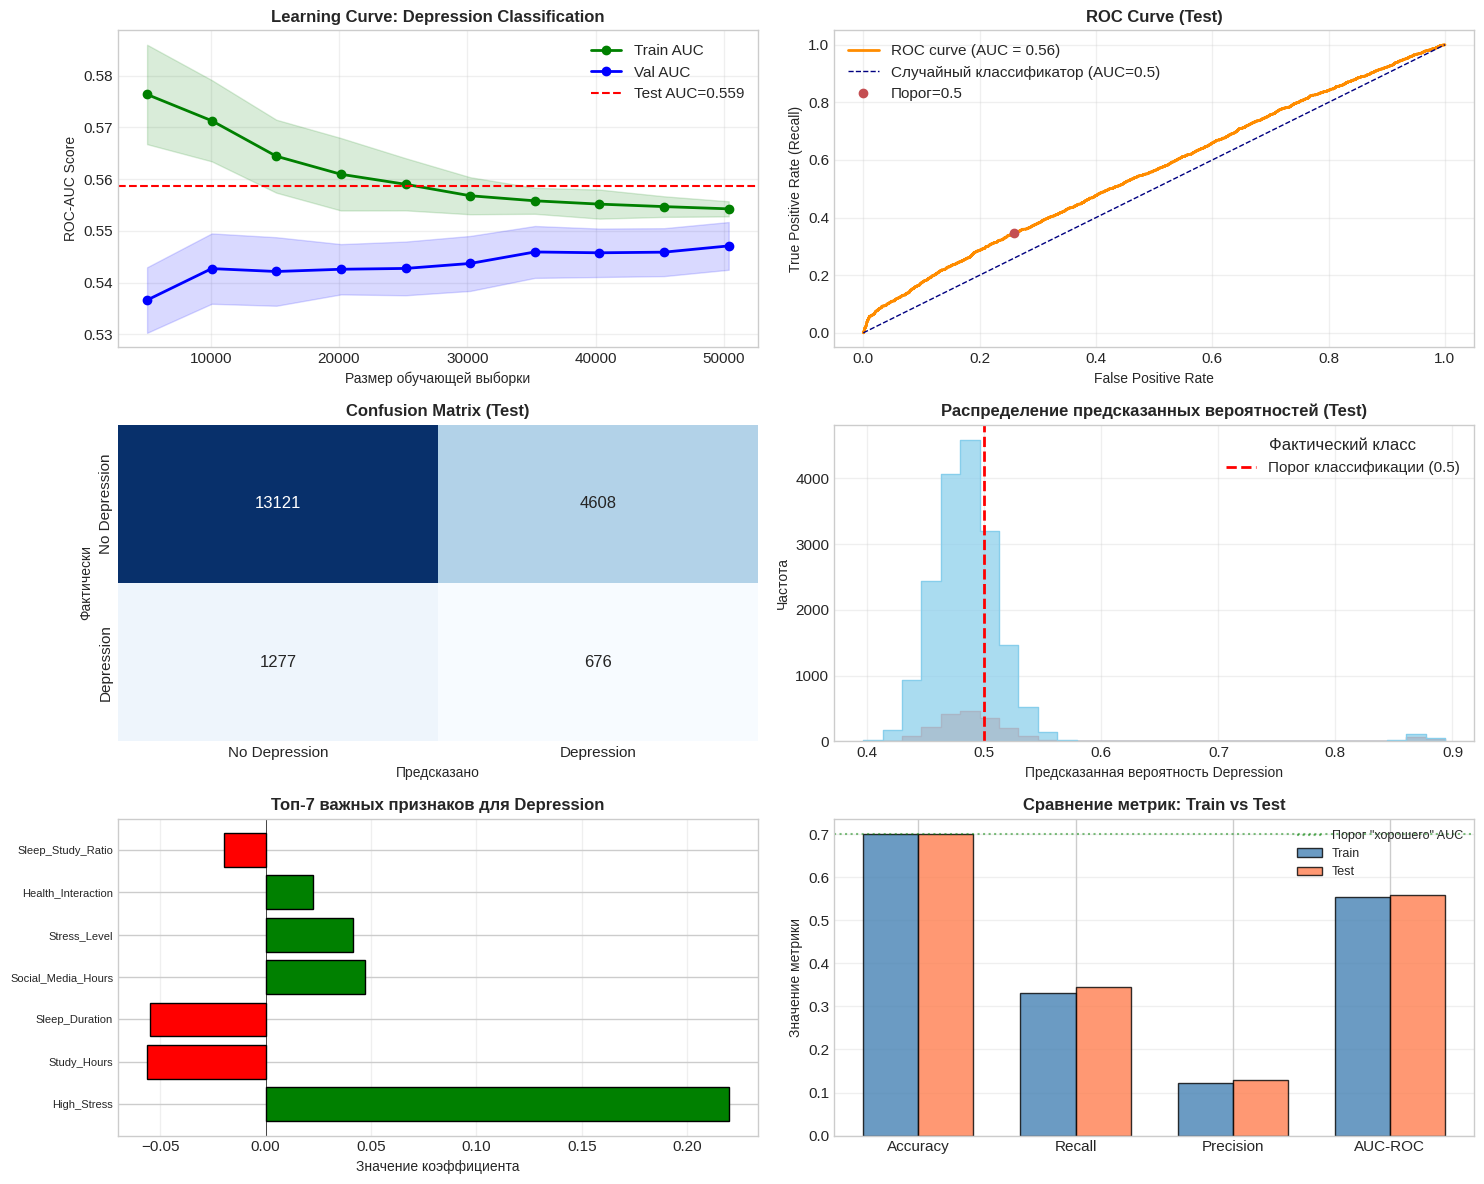


 Диагностика классификации:
  Разница AUC-ROC (Train - Test): -0.0051
  Модель обобщает данные адекватно (разница AUC < 0.1)

 Анализ метрики Recall:
  Recall на тесте: 0.3461
  Интерпретация: из 100 студентов с депрессией модель правильно
  идентифицирует 34.6 человек.
 Recall < 0.5 — модель пропускает много случаев депрессии

Топ-7 факторов, повышающих риск депрессии:
  + High_Stress: 0.220
  + Social_Media_Hours: 0.047
  + Stress_Level: 0.042
  + Health_Interaction: 0.022

 Топ-7 факторов, понижающих риск депрессии:
  - Study_Hours: -0.056
  - Sleep_Duration: -0.055
  - Sleep_Study_Ratio: -0.020

 Анализ различных порогов классификации:
  Порог 0.3: Precision=0.099, Recall=1.000
  Порог 0.4: Precision=0.099, Recall=1.000
  Порог 0.5: Precision=0.128, Recall=0.346
  Порог 0.6: Precision=0.379, Recall=0.053
  Порог 0.7: Precision=0.379, Recall=0.053

 Совет: если важна полнота (Recall), снизьте порог до 0.3–0.4.
   Если важна точность (Precision), повысьте порог до 0.6–0.7.


In [18]:
# Обучение
# Логистическая регрессия
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, auc,
                             roc_auc_score, roc_curve, log_loss, confusion_matrix,classification_report)
from sklearn.model_selection import learning_curve

# ОБУЧЕНИЕ МОДЕЛИ

model_clf = LogisticRegression(max_iter=2000, random_state=random_st, class_weight='balanced')
model_clf.fit(X_train_scaled, y_clf_train)

y_clf_train_pred = model_clf.predict(X_train_scaled)
y_clf_val_pred = model_clf.predict(X_val_scaled)
y_clf_test_pred = model_clf.predict(X_test_scaled)

y_clf_train_proba = model_clf.predict_proba(X_train_scaled)[:, 1]
y_clf_val_proba = model_clf.predict_proba(X_val_scaled)[:, 1]
y_clf_test_proba = model_clf.predict_proba(X_test_scaled)[:, 1]

# ФУНКЦИЯ ПОТЕРЬ (Log Loss) для всех выборок

train_logloss = log_loss(y_clf_train, y_clf_train_proba)
val_logloss = log_loss(y_clf_val, y_clf_val_proba)
test_logloss = log_loss(y_clf_test, y_clf_test_proba)

print(f"Train Loss (Log Loss): {train_logloss:.4f}")
print(f"Val Loss (Log Loss):   {val_logloss:.4f}")
print(f"Test Loss (Log Loss):  {test_logloss:.4f}")

# График сравнения Log Loss
plt.figure(figsize=(8, 5))
plt.bar(['Train', 'Validation', 'Test'], [train_logloss, val_logloss, test_logloss],
        color=['skyblue', 'lightgreen', 'pink'], edgecolor='black')
plt.ylabel('Loss (Log Loss)')
plt.title('Сравнение функции потерь на выборках')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ФУНКЦИЯ ОЦЕНКИ КАЧЕСТВА

def evaluate_classification(y_true, y_pred, y_proba, dataset_name="Dataset"):
    """Расчет и вывод метрик качества для классификации"""

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba)
    logloss = log_loss(y_true, y_proba)

    print(f"\n Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc_roc:.4f}")
    print(f"  Log Loss:  {logloss:.4f}")

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'AUC': auc_roc,
        'LogLoss': logloss
    }

# Оценка на train, validation и test
train_metrics_clf = evaluate_classification(y_clf_train, y_clf_train_pred, y_clf_train_proba, "Train")
val_metrics_clf = evaluate_classification(y_clf_val, y_clf_val_pred, y_clf_val_proba, "Validation")
test_metrics_clf = evaluate_classification(y_clf_test, y_clf_test_pred, y_clf_test_proba, "Test")

# Вывод полного отчёта для теста
print(f"\n Classification Report (Test):")
print(classification_report(y_clf_test, y_clf_test_pred, target_names=['No Depression', 'Depression']))


# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 12))

# Learning Curve (Кривая обучения)
ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model_clf, X_train_scaled, y_clf_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=random_st,
    shuffle=True
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train AUC', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val AUC', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('ROC-AUC Score', fontsize=10)
ax1.set_title('Learning Curve: Depression Classification', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_metrics_clf['AUC'], color='red', linestyle='--', lw=1.5,
            label=f'Test AUC={test_metrics_clf["AUC"]:.3f}')
ax1.legend()

# ROC-кривая
ax2 = plt.subplot(3, 2, 2)
fpr, tpr, thresholds = roc_curve(y_clf_test, y_clf_test_proba)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Случайный классификатор (AUC=0.5)')
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=10)
ax2.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# Добавим точку текущего порога (0.5)
idx = np.argmin(np.abs(thresholds - 0.5))
ax2.plot(fpr[idx], tpr[idx], 'ro', label=f'Порог=0.5')
ax2.legend()

# Confusion Matrix
ax3 = plt.subplot(3, 2, 3)
cm = confusion_matrix(y_clf_test, y_clf_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
ax3.set_xlabel('Предсказано', fontsize=10)
ax3.set_ylabel('Фактически', fontsize=10)
ax3.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')

# Распределение предсказанных вероятностей
ax4 = plt.subplot(3, 2, 4)
df_proba = pd.DataFrame({'proba': y_clf_test_proba, 'true': y_clf_test})
sns.histplot(data=df_proba, x='proba', hue='true', bins=30, ax=ax4,
             palette={0: 'skyblue', 1: 'salmon'}, alpha=0.7, element='step')
ax4.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог классификации (0.5)')
ax4.set_xlabel('Предсказанная вероятность Depression', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение предсказанных вероятностей (Test)', fontsize=12, fontweight='bold')
ax4.legend(title='Фактический класс')
ax4.grid(True, alpha=0.3)

# Коэффициенты модели
ax5 = plt.subplot(3, 2, 5)

# Получаем названия признаков
if hasattr(X, 'columns'):
    feature_names = X.columns.tolist()
else:
    feature_names = [f'Feature_{i}' for i in range(X_train_scaled.shape[1])]

# Извлекаем коэффициенты (для LogisticRegression coef_ может быть 2D)
coef_values = model_clf.coef_[0] if model_clf.coef_.ndim > 1 else model_clf.coef_

coefficients_clf = pd.DataFrame({
    'feature': feature_names,
    'coef': coef_values
})
coefficients_clf = coefficients_clf.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(7)

colors = ['green' if c > 0 else 'red' for c in coefficients_clf['coef']]
bars = ax5.barh(coefficients_clf['feature'], coefficients_clf['coef'],
                color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-7 важных признаков для Depression', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)


# Сравнение метрик Train/Test
ax6 = plt.subplot(3, 2, 6)
metrics_names = ['Accuracy', 'Recall','Precision', 'AUC-ROC']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics_clf['Accuracy'], train_metrics_clf['Recall'],train_metrics_clf['Precision'], train_metrics_clf['AUC']]
test_vals = [test_metrics_clf['Accuracy'], test_metrics_clf['Recall'],test_metrics_clf['Precision'], test_metrics_clf['AUC']]

ax6.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8,
        edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8,
        edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(metrics_names)
ax6.set_ylabel('Значение метрики', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Добавим горизонтальную линию "хорошего" порога для AUC
ax6.axhline(y=0.7, color='green', linestyle=':', alpha=0.5, label='Порог "хорошего" AUC')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ДИАГНОСТИКА: переобучение и анализ

# Проверка на переобучение по AUC-ROC
auc_diff = train_metrics_clf['AUC'] - test_metrics_clf['AUC']
print(f"\n Диагностика классификации:")
print(f"  Разница AUC-ROC (Train - Test): {auc_diff:.4f}")

if auc_diff > 0.1:
    print("   Возможное переобучение!")
elif auc_diff < -0.1:
    print("   Необычная ситуация: тест лучше трейна.")
    print("   Проверьте, нет ли утечки данных или ошибки в разделении.")
else:
    print("  Модель обобщает данные адекватно (разница AUC < 0.1)")

# Анализ важности Recall для задачи депрессии
print(f"\n Анализ метрики Recall:")
print(f"  Recall на тесте: {test_metrics_clf['Recall']:.4f}")
print(f"  Интерпретация: из 100 студентов с депрессией модель правильно")
print(f"  идентифицирует {test_metrics_clf['Recall']*100:.1f} человек.")

if test_metrics_clf['Recall'] >= 0.7:
    print(" Recall ≥ 0.7 — хороший результат для скрининговой задачи")
elif test_metrics_clf['Recall'] >= 0.5:
    print(" Recall 0.5–0.7 — приемлемо")
else:
    print(" Recall < 0.5 — модель пропускает много случаев депрессии")

# Топ-7 факторов риска и защиты
print(f"\nТоп-7 факторов, повышающих риск депрессии:")
top_positive = coefficients_clf[coefficients_clf['coef'] > 0].head(7)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['coef']:.3f}")

print(f"\n Топ-7 факторов, понижающих риск депрессии:")
top_negative = coefficients_clf[coefficients_clf['coef'] < 0].head(7)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['coef']:.3f}")


# ДОПОЛНИТЕЛЬНО: анализ влияния порога классификации
print(f"\n Анализ различных порогов классификации:")
thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7]

for thresh in thresholds_to_check:
    y_pred_thresh = (y_clf_test_proba >= thresh).astype(int)
    prec = precision_score(y_clf_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_clf_test, y_pred_thresh, zero_division=0)
    print(f"  Порог {thresh:.1f}: Precision={prec:.3f}, Recall={rec:.3f}")

print(f"\n Совет: если важна полнота (Recall), снизьте порог до 0.3–0.4.")
print(f"   Если важна точность (Precision), повысьте порог до 0.6–0.7.")


epochs=100: val AUC=0.5608, final val log_loss=0.6799
epochs=300: val AUC=0.5618, final val log_loss=0.6741
epochs=500: val AUC=0.5616, final val log_loss=0.6746


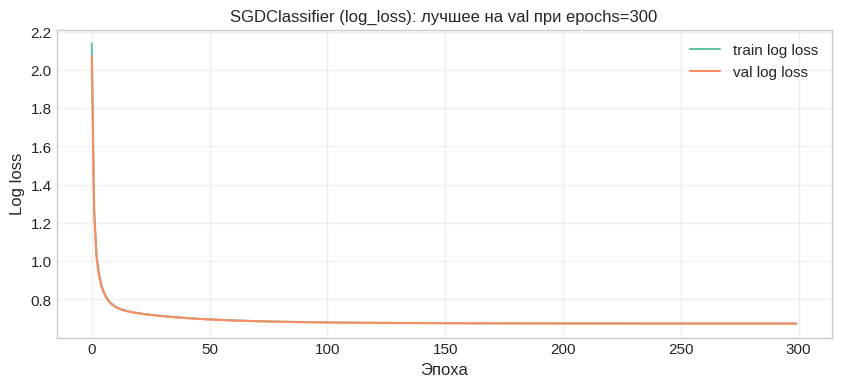

Тест SGD log-reg: AUC= 0.5553 log_loss= 0.6745


In [19]:
# Логистика (SGD)
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

def train_sgd_logistic_plain(X_tr, y_tr, X_va, y_va, epochs):
    classes = np.unique(y_tr)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_tr
    )
    class_weight_dict = dict(zip(classes, class_weights))

    # Инициализируем модель с вычисленными весами
    clf = SGDClassifier(
        loss='log_loss',
        max_iter=1000,
        warm_start=True,
        random_state=random_st,
        class_weight=class_weight_dict,  # Передаем вычисленные веса
    )

    train_ll, val_ll = [], []
    classes_unique = np.array([0, 1])

    for ep in range(epochs):
        if ep == 0:
            clf.partial_fit(X_tr, y_tr, classes=classes_unique)
        else:
            clf.partial_fit(X_tr, y_tr)

        train_ll.append(log_loss(y_tr, clf.predict_proba(X_tr)[:, 1]))
        val_ll.append(log_loss(y_va, clf.predict_proba(X_va)[:, 1]))

    auc_va = roc_auc_score(y_va, clf.predict_proba(X_va)[:, 1])
    return clf, train_ll, val_ll, auc_va

# Несколько длин обучения (как число эпох)
epoch_list = [100, 300, 500]
best = (-1.0, None, None)
for epochs in epoch_list:
    _, trl, vll, auc_va = train_sgd_logistic_plain(
        X_train_scaled, y_clf_train, X_val_scaled, y_clf_val, epochs
    )
    print(f'epochs={epochs}: val AUC={auc_va:.4f}, final val log_loss={vll[-1]:.4f}')
    if auc_va > best[0]:
        best = (auc_va, epochs, (trl, vll))

_, best_ep, curves = best
trl, vll = curves
plt.figure(figsize=(10, 4))
plt.plot(trl, label='train log loss')
plt.plot(vll, label='val log loss')
plt.xlabel('Эпоха')
plt.ylabel('Log loss')
plt.title(f'SGDClassifier (log_loss): лучшее на val при epochs={best_ep}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model_clf_sgd, _, _, _ = train_sgd_logistic_plain(
    X_train_scaled, y_clf_train, X_val_scaled, y_clf_val, best_ep
)
p_sgd_te = model_clf_sgd.predict_proba(X_test_scaled)[:, 1]
y_sgd_pred = model_clf_sgd.predict(X_test_scaled)
print('Тест SGD log-reg: AUC=', round(roc_auc_score(y_clf_test, p_sgd_te), 4),
      'log_loss=', round(log_loss(y_clf_test, p_sgd_te), 4))


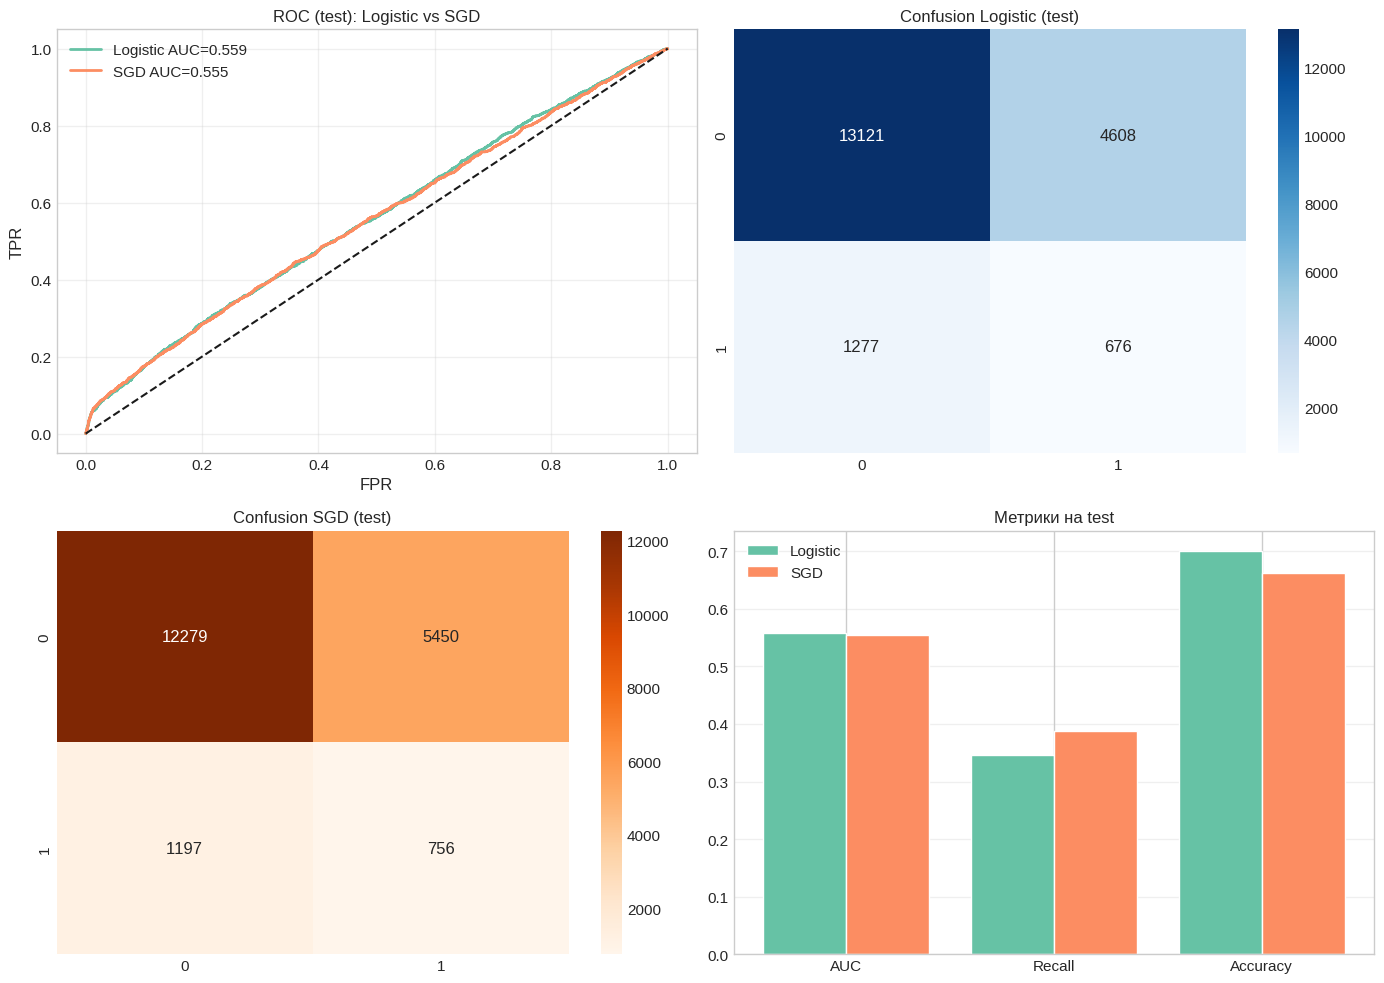

In [20]:
# Сравнение LogisticRegression и SGDClassifier на одних графиках (test)
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score, recall_score, accuracy_score

fpr_lr, tpr_lr, _ = roc_curve(y_clf_test, y_clf_test_proba)
fpr_sg, tpr_sg, _ = roc_curve(y_clf_test, p_sgd_te)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(fpr_lr, tpr_lr, lw=2, label=f'Logistic AUC={auc(fpr_lr, tpr_lr):.3f}')
axes[0, 0].plot(fpr_sg, tpr_sg, lw=2, label=f'SGD AUC={auc(fpr_sg, tpr_sg):.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('FPR')
axes[0, 0].set_ylabel('TPR')
axes[0, 0].set_title('ROC (test): Logistic vs SGD')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

cm_lr = confusion_matrix(y_clf_test, y_clf_test_pred)
cm_sg = confusion_matrix(y_clf_test, y_sgd_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Confusion Logistic (test)')
sns.heatmap(cm_sg, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0])
axes[1, 0].set_title('Confusion SGD (test)')

m = ['AUC', 'Recall', 'Accuracy']
lr_v = [test_metrics_clf['AUC'], test_metrics_clf['Recall'], test_metrics_clf['Accuracy']]
sg_v = [roc_auc_score(y_clf_test, p_sgd_te), recall_score(y_clf_test, y_sgd_pred, zero_division=0),
        accuracy_score(y_clf_test, y_sgd_pred)]
x = np.arange(len(m))
axes[1, 1].bar(x - 0.2, lr_v, 0.4, label='Logistic')
axes[1, 1].bar(x + 0.2, sg_v, 0.4, label='SGD')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(m)
axes[1, 1].set_title('Метрики на test')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Интерпретация: классификация (Depression) и сравнение LogisticRegression vs SGD

**Почему такие метрики.** Для бинарной классификации с сильным дисбалансом классов (много «нет депрессии», мало «есть»):
- **Accuracy** — вводит в заблуждение: высокая доля правильных ответов достигается, если почти всегда предсказывать мажорный класс. Поэтому по одной accuracy нельзя судить о качестве.
- **Precision / Recall** — разделяют ошибки I и II рода. Для скрининга депрессии часто важен **recall** (не пропустить людей с риском), даже ценой лишних срабатываний.
- **ROC-AUC** — качество ранжирования по вероятности класса «1»; не зависит от порога 0.5. Значения около **0.55** означают лишь небольшое преимущество перед случайным угадыванием (0.5).
- **Log loss** — штраф за калибровку вероятностей; при дисбалансе «низкий» log loss ещё не означает хорошую диагностическую ценность, если модель чаще предсказывает класс 0.

**Почему ROC-кривые близки к диагонали.** При AUC ≈ 0.55–0.56 признаки слабо отделяют классы в линейной модели на этих данных (или метка/призаки зашумлены).

**Почему кривая log loss по эпохам быстро выходит на плато.** Градиентный спуск быстро уменьшает loss на первых эпохах, затем улучшения малы; увеличение числа эпох без смены признаков/весов класса редко даёт большой прирост AUC.

**Чем датасет может быть «неудобным».** Дисбаланс классов; возможная **слабая предсказательная сила** признаков для цели; **шум и выбросы** в образе жизни; бинарная метка «депрессия» упрощает реальность.

Различия между **SGD** и **Logistic** незначительны, значит скорее всего проблема не в методе оптимизации, а в самих данных. Скорее всего линейные модели не подходят для этого датасета.


## Выводы (качество моделей и влияние предобработки)

- **Предобработка:** дубликаты и IQR по выбросам меняют объём выборки; `StandardScaler` и заполнение пропусков медианой *только с train* снижают утечку информации из test.
- **Регрессия (CGPA):** низкий **R²** при приемлемом **MAE** типичен, когда цель почти «плоская», а связь с признаками слабая и нелинейная; **LinearRegression** и **SGDRegressor** в таком случае дают близкие метрики.
- **Классификация:** следует опираться на **AUC, recall, precision**, а не на accuracy;
- **Общий вывод по датасету:** метрики указывают на **ограниченную разделимость** классов и слабое линейное объяснение CGPA.


## Дополнительно: логистическая регрессия на сбалансированной выборке

**Идея:** убрать искусственные веса классов (`class_weight`) и вместо этого изменить датасет — случайно уменьшить число объектов с `Depression == False` до числа объектов с `Depression == True` (undersampling мажорного класса), затем обучить ту же `LogisticRegression` и сравнить метрики и графики с основным экспериментом.

**Важно:** объём данных становится меньше; распределение признаков внутри каждого класса сохраняется за счёт случайной подвыборки строк с «No depression».


После предобработки (до баланса): 98409 строк, класс 1: 9766
После undersampling + OHE: 19532 строк, y: {0: 9766, 1: 9766}
Train Loss (Log Loss): 0.6812
Val Loss (Log Loss):   0.6761
Test Loss (Log Loss):  0.6865


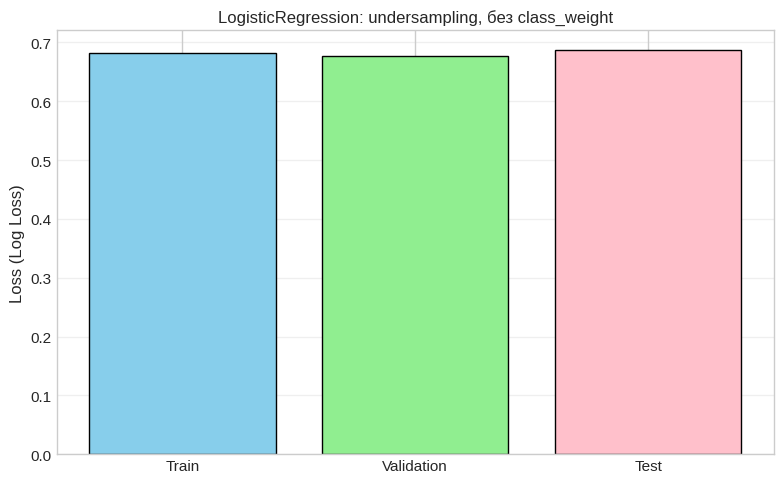


 Метрики для Train:
  Accuracy:  0.5468
  Precision: 0.5599
  Recall:    0.4374
  AUC-ROC:   0.5646
  Log Loss:  0.6812

 Метрики для Validation:
  Accuracy:  0.5450
  Precision: 0.5564
  Recall:    0.4424
  AUC-ROC:   0.5532
  Log Loss:  0.6761

 Метрики для Test:
  Accuracy:  0.5173
  Precision: 0.5231
  Recall:    0.3941
  AUC-ROC:   0.5348
  Log Loss:  0.6865

 Classification Report (Test):
               precision    recall  f1-score   support

No Depression       0.51      0.64      0.57      1953
   Depression       0.52      0.39      0.45      1954

     accuracy                           0.52      3907
    macro avg       0.52      0.52      0.51      3907
 weighted avg       0.52      0.52      0.51      3907



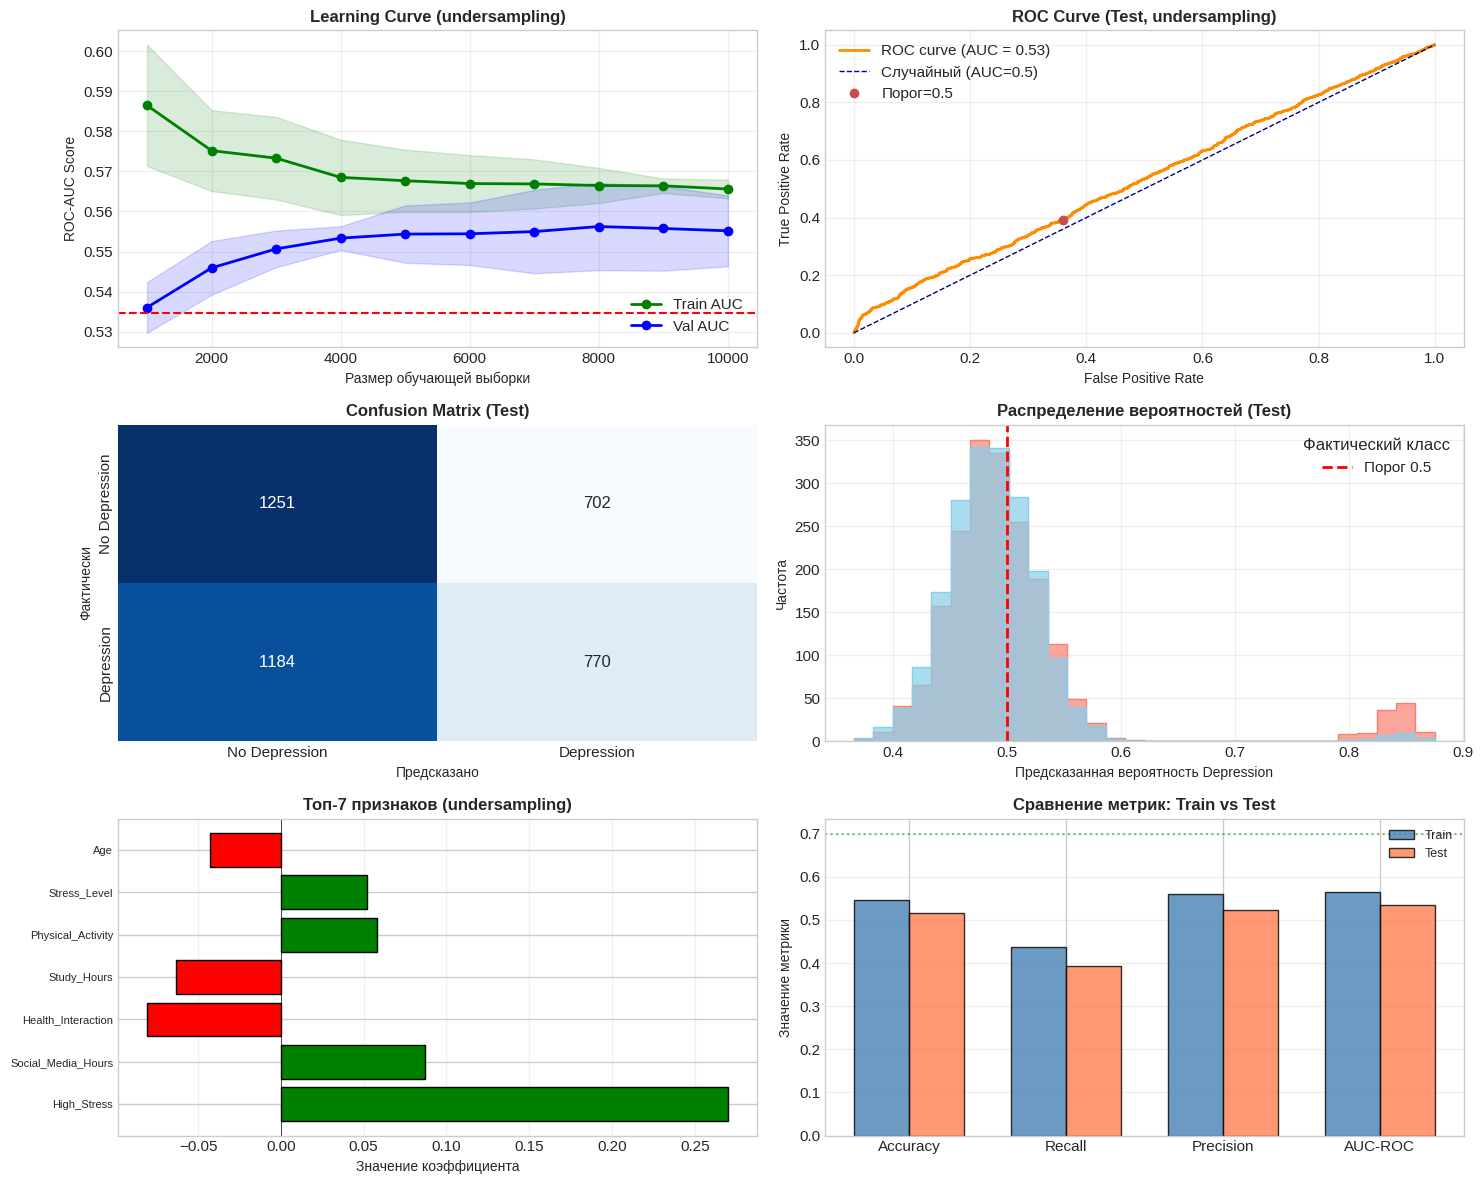


 Диагностика: разница AUC-ROC (Train - Test): 0.0298
  Разница AUC < 0.1.

 Recall на тесте: 0.3941

Топ-7 факторов риска (положительные коэффициенты):
  + High_Stress: 0.270
  + Social_Media_Hours: 0.087
  + Physical_Activity: 0.058
  + Stress_Level: 0.052

Топ-7 факторов защиты (отрицательные):
  - Health_Interaction: -0.081
  - Study_Hours: -0.063
  - Age: -0.043

 Пороги классификации (test):
  Порог 0.3: Precision=0.500, Recall=1.000
  Порог 0.4: Precision=0.501, Recall=0.992
  Порог 0.5: Precision=0.523, Recall=0.394
  Порог 0.6: Precision=0.803, Recall=0.058
  Порог 0.7: Precision=0.806, Recall=0.057

Разница AUC (Train - Test), вероятностная: 0.0298


In [21]:
# Логистическая регрессия на вручную сбалансированной выборке (аналог ячейки с class_weight='balanced'):
# undersampling класса «нет депрессии», затем One-Hot и разбиение — как в основном пайплайне

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, auc,
    roc_auc_score, roc_curve, log_loss, confusion_matrix, classification_report,
)

_DATA_CSV = '/content/student_lifestyle_100k.csv'


def _df_before_ohe():
    """Повторяет ноутбук до ячейки «Кодирование»: загрузка, дубли, без Gender/Age, IQR, FE."""
    d = pd.read_csv(_DATA_CSV, sep=',')
    d.drop(columns='Student_ID', inplace=True, errors='ignore')
    for c in d.select_dtypes(include=['object']).columns:
        d[c] = d[c].astype(str).str.strip()
    if 'Age' in d.columns:
        bad = (d['Age'] < 15) | (d['Age'] > 70)
        if bad.any():
            d.loc[bad, 'Age'] = np.nan
        d['Age'] = d['Age'].clip(lower=17, upper=70)
    for c in ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']:
        if c in d.columns:
            d.loc[d[c] < 0, c] = np.nan
    d['Physical_Activity'] = d['Physical_Activity'].astype('int16')
    for i in ['Age', 'Stress_Level']:
        if i in d.columns:
            d[i] = d[i].astype('int8')
    for i in ['Gender', 'Department']:
        if i in d.columns:
            d[i] = d[i].astype('category')
    d = d.drop_duplicates()
    #d = d.drop(columns=['Gender', 'Age'], errors='ignore')
    num_cols = d.select_dtypes(include='number').columns.tolist()
    for col in num_cols:
        col_data = d[col].dropna()
        if len(col_data) > 0:
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1
            lo = Q1 - 1.5 * IQR
            hi = Q3 + 1.5 * IQR
            d = d[~((d[col] < lo) | (d[col] > hi))]
    d.reset_index(drop=True, inplace=True)
    d['Sleep_Study_Ratio'] = d['Sleep_Duration'] / (d['Study_Hours'] + 0.0001)
    d['Health_Interaction'] = d['Physical_Activity'] * d['Sleep_Duration']
    d['High_Stress'] = (d['Stress_Level'] >= 8).astype(int)
    return d


def _depression_as_int(s):
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(int)
    sl = s.astype(str).str.strip().str.lower()
    m = sl.map({'true': 1, 'false': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0})
    if m.notna().all():
        return m.astype(int)
    return pd.to_numeric(s, errors='coerce').fillna(0).astype(int)


df_pre = _df_before_ohe()
if 'Depression' not in df_pre.columns:
    raise KeyError("Нет столбца Depression до кодирования — проверьте CSV.")
y_bin = _depression_as_int(df_pre['Depression'])
n_dep = int((y_bin == 1).sum())
df_pos = df_pre.loc[y_bin == 1].copy()
df_neg = df_pre.loc[y_bin == 0].copy()
df_neg_sub = df_neg.sample(n=n_dep, random_state=random_st, replace=False)
df_bal = pd.concat([df_pos, df_neg_sub], axis=0).sample(frac=1.0, random_state=random_st).reset_index(drop=True)
df_bal['Depression'] = _depression_as_int(df_bal['Depression'])

cat_for_ohe = [
    c for c in df_bal.select_dtypes(include=['object', 'category']).columns.tolist()
    if c != 'Depression'
]
if cat_for_ohe:
    ohe_b = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    enc = ohe_b.fit_transform(df_bal[cat_for_ohe])
    ohe_names = ohe_b.get_feature_names_out(cat_for_ohe)
    df_bal = df_bal.drop(columns=cat_for_ohe)
    df_bal = pd.concat(
        [df_bal, pd.DataFrame(enc, columns=ohe_names, index=df_bal.index)], axis=1
    )

print(f"После предобработки (до баланса): {len(df_pre)} строк, класс 1: {n_dep}")
print(f"После undersampling + OHE: {len(df_bal)} строк, y: {df_bal['Depression'].value_counts().to_dict()}")

X_u = df_bal.drop(columns=['CGPA', 'Depression'])
y_reg_u = df_bal['CGPA']
y_clf_u = df_bal['Depression'].astype(int)
numeric_cols_u = X_u.select_dtypes(include=[np.number]).columns.tolist()

X_u_tv, X_u_te, y_reg_u_tv, y_reg_u_te, y_clf_u_tv, y_clf_u_te = train_test_split(
    X_u, y_reg_u, y_clf_u, test_size=0.2, random_state=random_st, stratify=y_clf_u
)
X_u_tr, X_u_va, y_reg_u_tr, y_reg_u_va, y_clf_u_tr, y_clf_u_va = train_test_split(
    X_u_tv, y_reg_u_tv, y_clf_u_tv, test_size=0.2, random_state=random_st, stratify=y_clf_u_tv
)

for d_ in [X_u_tr, X_u_va, X_u_te]:
    d_.replace([np.inf, -np.inf], np.nan, inplace=True)
    d_.fillna(X_u_tr.median(), inplace=True)

scaler_u = StandardScaler()
X_u_train_s = scaler_u.fit_transform(X_u_tr[numeric_cols_u])
X_u_val_s = scaler_u.transform(X_u_va[numeric_cols_u])
X_u_test_s = scaler_u.transform(X_u_te[numeric_cols_u])
if len(X_u.columns) > len(numeric_cols_u):
    cat_u = [c for c in X_u.columns if c not in numeric_cols_u]
    X_u_train_s = np.hstack([X_u_train_s, X_u_tr[cat_u].values])
    X_u_val_s = np.hstack([X_u_val_s, X_u_va[cat_u].values])
    X_u_test_s = np.hstack([X_u_test_s, X_u_te[cat_u].values])

model_clf_u = LogisticRegression(max_iter=2000, random_state=random_st)
model_clf_u.fit(X_u_train_s, y_clf_u_tr)

y_u_train_pred = model_clf_u.predict(X_u_train_s)
y_u_val_pred = model_clf_u.predict(X_u_val_s)
y_u_test_pred = model_clf_u.predict(X_u_test_s)
y_u_train_proba = model_clf_u.predict_proba(X_u_train_s)[:, 1]
y_u_val_proba = model_clf_u.predict_proba(X_u_val_s)[:, 1]
y_u_test_proba = model_clf_u.predict_proba(X_u_test_s)[:, 1]

train_ll_u = log_loss(y_clf_u_tr, y_u_train_proba)
val_ll_u = log_loss(y_clf_u_va, y_u_val_proba)
test_ll_u = log_loss(y_clf_u_te, y_u_test_proba)
print(f"Train Loss (Log Loss): {train_ll_u:.4f}")
print(f"Val Loss (Log Loss):   {val_ll_u:.4f}")
print(f"Test Loss (Log Loss):  {test_ll_u:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(['Train', 'Validation', 'Test'], [train_ll_u, val_ll_u, test_ll_u],
        color=['skyblue', 'lightgreen', 'pink'], edgecolor='black')
plt.ylabel('Loss (Log Loss)')
plt.title('LogisticRegression: undersampling, без class_weight')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


def evaluate_classification_u(y_true, y_pred, y_proba, dataset_name="Dataset"):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba)
    ll = log_loss(y_true, y_proba)
    print(f"\n Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc_roc:.4f}")
    print(f"  Log Loss:  {ll:.4f}")
    return {
        'Accuracy': accuracy, 'Precision': precision, 'Recall': recall,
        'AUC': auc_roc, 'LogLoss': ll,
    }


train_m_u = evaluate_classification_u(y_clf_u_tr, y_u_train_pred, y_u_train_proba, "Train")
val_m_u = evaluate_classification_u(y_clf_u_va, y_u_val_pred, y_u_val_proba, "Validation")
test_m_u = evaluate_classification_u(y_clf_u_te, y_u_test_pred, y_u_test_proba, "Test")
print(f"\n Classification Report (Test):")
print(classification_report(y_clf_u_te, y_u_test_pred, target_names=['No Depression', 'Depression']))

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 12))

ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores_u, val_scores_u = learning_curve(
    model_clf_u, X_u_train_s, y_clf_u_tr, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc', n_jobs=-1,
    random_state=random_st, shuffle=True,
)
train_mean = np.mean(train_scores_u, axis=1)
train_std = np.std(train_scores_u, axis=1)
val_mean = np.mean(val_scores_u, axis=1)
val_std = np.std(val_scores_u, axis=1)
ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train AUC', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val AUC', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('ROC-AUC Score', fontsize=10)
ax1.set_title('Learning Curve (undersampling)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_m_u['AUC'], color='red', linestyle='--', lw=1.5)

ax2 = plt.subplot(3, 2, 2)
fpr_u, tpr_u, thresholds_u = roc_curve(y_clf_u_te, y_u_test_proba)
roc_auc_u = auc(fpr_u, tpr_u)
ax2.plot(fpr_u, tpr_u, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_u:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Случайный (AUC=0.5)')
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.set_title('ROC Curve (Test, undersampling)', fontsize=12, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)
idx_u = np.argmin(np.abs(thresholds_u - 0.5))
ax2.plot(fpr_u[idx_u], tpr_u[idx_u], 'ro', label='Порог=0.5')
ax2.legend()

ax3 = plt.subplot(3, 2, 3)
cm_u = confusion_matrix(y_clf_u_te, y_u_test_pred)
sns.heatmap(cm_u, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
ax3.set_xlabel('Предсказано', fontsize=10)
ax3.set_ylabel('Фактически', fontsize=10)
ax3.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')

ax4 = plt.subplot(3, 2, 4)
df_proba_u = pd.DataFrame({'proba': y_u_test_proba, 'true': y_clf_u_te})
sns.histplot(data=df_proba_u, x='proba', hue='true', bins=30, ax=ax4,
             palette={0: 'skyblue', 1: 'salmon'}, alpha=0.7, element='step')
ax4.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог 0.5')
ax4.set_xlabel('Предсказанная вероятность Depression', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение вероятностей (Test)', fontsize=12, fontweight='bold')
ax4.legend(title='Фактический класс')
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 2, 5)
if hasattr(X_u, 'columns'):
    feature_names_u = X_u.columns.tolist()
else:
    feature_names_u = [f'Feature_{i}' for i in range(X_u_train_s.shape[1])]
coef_values_u = model_clf_u.coef_[0] if model_clf_u.coef_.ndim > 1 else model_clf_u.coef_
coefficients_u = pd.DataFrame({'feature': feature_names_u, 'coef': coef_values_u})
coefficients_u = coefficients_u.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(7)
colors_u = ['green' if c > 0 else 'red' for c in coefficients_u['coef']]
ax5.barh(coefficients_u['feature'], coefficients_u['coef'], color=colors_u, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-7 признаков (undersampling)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

ax6 = plt.subplot(3, 2, 6)
metrics_names = ['Accuracy', 'Recall', 'Precision', 'AUC-ROC']
x_pos = np.arange(len(metrics_names))
width = 0.35
train_vals_u = [train_m_u['Accuracy'], train_m_u['Recall'], train_m_u['Precision'], train_m_u['AUC']]
test_vals_u = [test_m_u['Accuracy'], test_m_u['Recall'], test_m_u['Precision'], test_m_u['AUC']]
ax6.bar(x_pos - width/2, train_vals_u, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals_u, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(metrics_names)
ax6.set_ylabel('Значение метрики', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')
ax6.axhline(y=0.7, color='green', linestyle=':', alpha=0.5)
ax6.legend(fontsize=9)

plt.tight_layout()
plt.show()

auc_diff_u = train_m_u['AUC'] - test_m_u['AUC']
print(f"\n Диагностика: разница AUC-ROC (Train - Test): {auc_diff_u:.4f}")
if auc_diff_u > 0.1:
    print("  Возможное переобучение.")
elif auc_diff_u < -0.1:
    print("  Тест выше трейна — проверьте разбиение.")
else:
    print("  Разница AUC < 0.1.")

print(f"\n Recall на тесте: {test_m_u['Recall']:.4f}")
print(f"\nТоп-7 факторов риска (положительные коэффициенты):")
for _, row in coefficients_u[coefficients_u['coef'] > 0].head(7).iterrows():
    print(f"  + {row['feature']}: {row['coef']:.3f}")
print(f"\nТоп-7 факторов защиты (отрицательные):")
for _, row in coefficients_u[coefficients_u['coef'] < 0].head(7).iterrows():
    print(f"  - {row['feature']}: {row['coef']:.3f}")

print(f"\n Пороги классификации (test):")
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pt = (y_u_test_proba >= thresh).astype(int)
    print(f"  Порог {thresh:.1f}: Precision={precision_score(y_clf_u_te, y_pt, zero_division=0):.3f}, "
          f"Recall={recall_score(y_clf_u_te, y_pt, zero_division=0):.3f}")

auc_gap_u = roc_auc_score(y_clf_u_tr, y_u_train_proba) - roc_auc_score(y_clf_u_te, y_u_test_proba)
print(f"\nРазница AUC (Train - Test), вероятностная: {auc_gap_u:.4f}")


|Test|	С удалением Gender/Age|	Без удаления|
|--------|-------|------|
|Accuracy | 0.519 | 0.517|
|Precision|0.525 |0.523|
|Recall | 0.387 | 0.394|
|AUC-ROC| 0.541 |0.535|
|Log loss| 0.685| 0.687|


Изменений почти нет, значит Пол и Возраст почти не влияют на предсказания


|Метрика|	Дисбаланс + balanced|	Сбалансированная выборка (undersampling), test|
|---|-----|---|
|Accuracy|0.701|0.519|
|Precision|0.128|0.525|
|Recall|0.346|0.387|
|AUC-ROC|0.559|0.541|
|Log loss|0.677|0.685|


### Accuracy
На несбалансированных данных ~0.70 в основном отражает правильное угадывание доминирующего класса «No Depression». После undersampling классы 50/50, поэтому ~0.52 — другая шкала: это уже «ошибка по обоим классам поровну», а не «почти всегда предсказать No». Прямо сравнивать эти два accuracy нельзя как «лучше/хуже модель».
### Precision по «Depression»
По сравнению с вариантом `class_weight='balanced'` precision по классу 1 на test заметно выше (в таблице ~0.13 -> ~0.53): среди тех, кого модель относит к депрессии, доля верных больше — меньше ложных тревог относительно числа срабатываний по классу 1.
### Recall по «Depression»
Небольшое изменение по сравнению с balanced (в таблице ~0.35 -> ~0.39 на test при пороге 0.5): полнота остаётся умеренной; при очень низком пороге (0.3–0.4) recall на test может быть близок к 1 за счёт резкого падения precision — но это смена правила по вероятности, а не улучшение модели.
### AUC-ROC
Небольшое снижение относительно balanced на test (в таблице ~0.559 -> ~0.541, разница порядка 0.018): для слабой модели это может быть и шум, и лёгкий спад ранжирования; оба значения остаются в зоне слабого разделения классов.
### Log loss
На сбалансированном по строкам варианте log loss на test чуть выше, чем у balanced (в таблице ~0.677 -> ~0.685): вероятности по этой метрике чуть хуже калибруются на test.